# Modelling the impact of climate variation on influenza in Australian States and Territories

Date: sept 2024

Author: Aminath Shausan
 

#### **Load libraries**

In [ ]:
# !python --version

In [22]:
path = '/Users/sha481/Documents/GitHub/climate_project/'
import warnings
warnings.filterwarnings("ignore")
import random
random.seed(113)

# np.random.seed(44) #numpy random seed

In [23]:
#import libraries
from datetime import datetime
import pandas as pd
import numpy as np

######## for Elastic net regression 
from sklearn.model_selection import cross_val_score # for cross validation
# # from sklearn.linear_model import Ridge # for Ridge regression
# # from sklearn.linear_model import Lasso # for LASSO regression 
# # from sklearn.linear_model import LassoCV # for LASSO regression 
from sklearn.linear_model import ElasticNet # for ElasticNet regression 
from sklearn.linear_model import ElasticNetCV # for ElasticNet regression 
## from sklearn.svm import SVR #for support vector regression

from sklearn.pipeline import Pipeline #for using pipeline 
# from sklearn.preprocessing import StandardScaler #for scaling data to mean 0, unit variance
from sklearn.model_selection import GridSearchCV #for Grid Search cross validation
# from sklearn.model_selection import RandomizedSearchCV #for random grid search
from sklearn.metrics import (
    mean_squared_error,   #to compute RMSE
    mean_absolute_error,   #to compute RMSE
    mean_poisson_deviance
)
################ data preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)


########################################## for Gradiant Boosted Regression Tree
from sklearn import datasets, ensemble
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit 
from sklearn.linear_model import PoissonRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
 
################## for Statsmodel
import statsmodels.api as sm
# from statsmodels.discrete.discrete_model import NegativeBinomial ##
import statsmodels.discrete.discrete_model as dm
# import xarray as xr # to read netcdf (.nc) files
# import geopandas as gpd #reading shape files 
# import regionmask #to determine which geographic region each grid point belongs to 
#(https://regionmask.readthedocs.io/en/v0.2.0/generated/regionmask.Regions_cls.html)

# import cartopy.crs as ccrs # for plotting world map
# from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
# from matplotlib.lines import Line2D ## for legends 

# import scipy
# import scipy.linalg as linalg #for linear regression

# import json  #for saving results
# import pickle
# from matplotlib import pyplot as plt

In [3]:
## for plotting
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors     

from IPython.display import set_matplotlib_formats
set_matplotlib_formats('png')
# plt.rcParams['savefig.dpi'] = 75
plt.rcParams['figure.autolayout'] = False
plt.rcParams['figure.figsize'] = (21, 30)  # A4
plt.rcParams['lines.linewidth'] = 2.0
plt.rcParams['lines.markersize'] = 8
#plt.rcParams['text.usetex'] = True
plt.rcParams['text.usetex'] = False
plt.rcParams['font.size'] = 16
plt.rcParams['legend.fontsize'] = 16
#plt.rcParams['font.family'] = "serif"
plt.rcParams['font.family'] = "sans"
matplotlib.rcParams['xtick.major.pad']=12
matplotlib.rcParams['ytick.major.pad']=12

In [4]:
## for plotting pdf
def plot_hist(data_mean, data_mean_all, color, ymax, density, label, lower_quantile=0.1, upper_quantile=0.9):

    pdf, bin_edges = np.histogram(data_mean, bins=10, density=density)
    if data_mean_all is None:
        data_mean_all = np.mean(data_mean)
        data_var_all = np.var(data_mean)
        print(label, data_mean_all)
        #print(label, data_mean_all, data_var_all)
    if ymax is None:
        ymax=np.max(pdf)*1.1
    plt.bar((bin_edges[:-1]+bin_edges[1:])/2.0, pdf, width=(bin_edges[1]-bin_edges[0])*0.9, color=color, alpha=0.3, label=label)
    plt.plot([data_mean_all,data_mean_all], [0,ymax], '--', color=color, linewidth=3)
    if lower_quantile is not None:
        lower_quantile_value = np.quantile(data_mean,lower_quantile)
        plt.plot([lower_quantile_value,lower_quantile_value], [0,ymax], ':', color=color, linewidth=3)
    if upper_quantile is not None:
        upper_quantile_value = np.quantile(data_mean,upper_quantile)
        plt.plot([upper_quantile_value,upper_quantile_value], [0,ymax], ':', color=color, linewidth=3)

## Load influenza data 

In [25]:
##read influenza data upto Dec 2019
df_flu = pd.read_csv(path + 'data/pathogen/influenza_by_state_by_yearMonth_18Sept2024.csv', low_memory=False) ##1260 rows × 3 columns #-- act not included and upto end of 2019
# df_flu = pd.read_csv(path + 'data/pathogen/influenza_by_state_by_yearMonth_06March2025.csv', low_memory=False) ##1536 rows × 9 columns #-- act included and upto end of 2023
df_flu['date'] = pd.to_datetime(df_flu[['year', 'month']].assign(DAY=1))
### df_flu = df_flu[df_flu['year'] < 2020]  ##1008 rows × 7 columns
df_flu = df_flu[['state', 'date', 'year', 'month', 'observed', 'popn', 'season']]  
print(df_flu.state.unique()) ## ['NSW' 'NT' 'QLD' 'SA' 'TAS' 'VIC' 'WA'] ['ACT' 'NSW' 'NT' 'QLD' 'SA' 'TAS' 'VIC' 'WA']
print(df_flu.year.unique()) ##[2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019] ; [2008 - 2023]
print(df_flu.dtypes)

df_flu


['NSW' 'NT' 'QLD' 'SA' 'TAS' 'VIC' 'WA']
[2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021
 2022]
state               object
date        datetime64[ns]
year                 int64
month                int64
observed             int64
popn               float64
season              object
dtype: object


,state,date,year,month,observed,popn,season
0,NSW,2008-01-01,2008,1,12,6919907.0,summer
1,NSW,2008-02-01,2008,2,27,6919907.0,summer
2,NSW,2008-03-01,2008,3,44,6919907.0,autumn
3,NSW,2008-04-01,2008,4,31,6943461.0,autumn
4,NSW,2008-05-01,2008,5,90,6943461.0,autumn
...,...,...,...,...,...,...,...
1255,WA,2022-08-01,2022,8,1661,2812331.0,winter
1256,WA,2022-09-01,2022,9,625,2812331.0,spring
1257,WA,2022-10-01,2022,10,314,2834117.0,spring
1258,WA,2022-11-01,2022,11,312,2834117.0,spring


In [26]:
### load barra2 climate data 
df_barra = pd.read_csv(path + 'data/climate_data/barra2/barra2_allAU.csv', low_memory=False) 
df_barra['date'] = pd.to_datetime(df_barra[['year', 'month']].assign(DAY=1))
df_barra = df_barra[df_barra['year'] > 2007]  ##1008 rows  ; 1728 rows
df_barra['dtr'] = df_barra['tasmax'] - df_barra['tasmin'] 
# print(df_barra.dtypes)
print(df_barra.jurisdiction.unique())  ## ['AUS' 'NSW' 'NT' 'QLD' 'SA' 'TAS' 'VIC' 'WA']
print(df_barra.year.unique()) ### [2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019]
# df_barra = df_barra[df_barra.jurisdiction != 'AUS'] ## remove AUS rows

df_barra = df_barra[['jurisdiction', 'date', 'year', 'month', 'tas', 'dtr', 'RH']] ## 1008 by 6 cols
# print(df_barra.jurisdiction.unique())
df_barra=df_barra.rename(columns = {'jurisdiction':'state'}) ## change column name

# print(df_barra.dtypes)

df_barra

['ACT' 'AUS' 'NSW' 'NT' 'QLD' 'SA' 'TAS' 'VIC' 'WA']
[2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021
 2022 2023]


,state,date,year,month,tas,dtr,RH
12,ACT,2008-01-01,2008,1,19.715080,12.589435,63.072355
13,ACT,2008-02-01,2008,2,16.034034,10.378778,68.181130
14,ACT,2008-03-01,2008,3,16.288459,12.576691,61.736041
15,ACT,2008-04-01,2008,4,10.445300,10.960686,69.406378
16,ACT,2008-05-01,2008,5,7.435386,11.545453,75.989721
...,...,...,...,...,...,...,...
1831,WA,2023-08-01,2023,8,13.241968,10.692650,76.032991
1832,WA,2023-09-01,2023,9,15.946798,10.161606,71.665917
1833,WA,2023-10-01,2023,10,18.598407,13.690662,56.308767
1834,WA,2023-11-01,2023,11,22.765627,14.583180,53.246542


In [27]:
### merge the health and climate data
df_merged = df_flu.merge(df_barra,  on = ['state','date'])
df_merged = df_merged[['state','date','year_x', 'month_x', 'observed', 'popn', 'season','tas',  'dtr',  'RH']] ## remove duplicate cols
df_merged = df_merged.rename(columns={'year_x':'year', 'month_x':'month'})
print(df_merged['state'].unique())
df_merged


['NSW' 'NT' 'QLD' 'SA' 'TAS' 'VIC' 'WA']


,state,date,year,month,observed,popn,season,tas,dtr,RH
0,NSW,2008-01-01,2008,1,12,6919907.0,summer,21.597086,9.013527,73.487414
1,NSW,2008-02-01,2008,2,27,6919907.0,summer,19.404524,8.187619,73.897354
2,NSW,2008-03-01,2008,3,44,6919907.0,autumn,19.029132,10.046147,70.250838
3,NSW,2008-04-01,2008,4,31,6943461.0,autumn,14.649582,8.304786,73.127066
4,NSW,2008-05-01,2008,5,90,6943461.0,autumn,12.482742,10.246951,72.962613
...,...,...,...,...,...,...,...,...,...,...
1255,WA,2022-08-01,2022,8,1661,2812331.0,winter,12.188047,9.233492,73.403589
1256,WA,2022-09-01,2022,9,625,2812331.0,spring,14.203520,10.015263,71.931392
1257,WA,2022-10-01,2022,10,314,2834117.0,spring,14.877061,11.545165,66.968810
1258,WA,2022-11-01,2022,11,312,2834117.0,spring,18.349941,12.645742,60.431537


In [28]:
## Add lag1 and lag2 cols for observed and lag 1 cols for climate variables for each state 

def get_state_data(stateName):
    ###################
    #state = name of state
    #########################
    # print(stateName)
    df_state = df_merged[df_merged['state']==stateName]
    
    #add lags and take logarithm
    # df_state[['obs_log', 'tas_log', 'dtr_log', 'RH_log']] = np.log(df_state[['observed', 'tas', 'dtr', 'RH']])  
    df_state[['obs_lag1', 'tas_lag1', 'dtr_lag1', 'RH_lag1']] = np.log(df_state[['observed', 'tas', 'dtr', 'RH']]).shift(1) #lag1 
    df_state[['obs_lag2']] = np.log(df_state[['observed']]).shift(2) #lag2
    # df_state[['check_obs_lag1', 'check_tas_lag1']] = np.log(df_state[['observed', 'tas', 'dtr', 'RH']].shift(1)) #lag1 
    # df_state[['check_obs_lag2']] = np.log(df_state[['observed']].shift(2)) #lag2
    # df_state = df_state.dropna() ## drop rows with NAN values 
 
    return df_state

In [30]:
df_combine.to_csv(path + 'data/pathogen/combinedInflClimate_24Fev2025.csv', index = False)
df_combine

,state,date,year,month,observed,popn,season,tas,dtr,RH,obs_lag1,tas_lag1,dtr_lag1,RH_lag1,obs_lag2
0,NSW,2008-01-01,2008,1,12,6919907.0,summer,21.597086,9.013527,73.487414,NaN,NaN,NaN,NaN,NaN
1,NSW,2008-02-01,2008,2,27,6919907.0,summer,19.404524,8.187619,73.897354,2.484907,3.072558,2.198726,4.297114,NaN
2,NSW,2008-03-01,2008,3,44,6919907.0,autumn,19.029132,10.046147,70.250838,3.295837,2.965506,2.102623,4.302677,2.484907
3,NSW,2008-04-01,2008,4,31,6943461.0,autumn,14.649582,8.304786,73.127066,3.784190,2.945971,2.307189,4.252072,3.295837
4,NSW,2008-05-01,2008,5,90,6943461.0,autumn,12.482742,10.246951,72.962613,3.433987,2.684412,2.116832,4.292199,3.784190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,NT,2022-08-01,2022,8,19,250704.0,winter,23.304053,15.960868,52.855533,5.631212,2.969869,2.770870,3.939695,7.821242
356,NT,2022-09-01,2022,9,11,250704.0,spring,26.669872,13.474216,59.204927,2.944439,3.148627,2.770140,3.967562,5.631212
357,NT,2022-10-01,2022,10,11,251248.0,spring,28.442622,11.448208,61.931695,2.397895,3.283535,2.600778,4.081005,2.944439
358,NT,2022-11-01,2022,11,6,251248.0,spring,28.216861,9.798516,65.072372,2.397895,3.347889,2.437833,4.126032,2.397895


In [20]:
# del df_combine
states = ['ACT', 'NSW', 'QLD', 'VIC', 'SA', 'TAS',  'WA', 'NT']
 
## combine state dfs vertically
df_combine = pd.concat([get_state_data('ACT'),get_state_data('NSW'), get_state_data('QLD'), get_state_data('VIC'), get_state_data('SA'), 
                       get_state_data('TAS'), get_state_data('WA'), get_state_data('NT')], axis=0) ## should give rows; with act should give 144*8 = 1536
print(df_combine.state.unique())

#save this df for modelling
df_combine.to_csv(path + 'data/pathogen/combinedInflClimate_24Fev2025.csv', index = False)
# df_combine.to_csv(path + 'data/pathogen/combinedInflClimate_06March2025.csv', index = False)
df_combine

['ACT' 'NSW' 'QLD' 'VIC' 'SA' 'TAS' 'WA' 'NT']


,state,date,year,month,observed,popn,season,tas,dtr,RH,obs_lag1,tas_lag1,dtr_lag1,RH_lag1,obs_lag2
0,ACT,2008-01-01,2008,1,16.0,346477.0,summer,19.715080,12.589435,63.072355,NaN,NaN,NaN,NaN,NaN
1,ACT,2008-02-01,2008,2,12.0,346477.0,summer,16.034034,10.378778,68.181130,2.772589,2.981384,2.532858,4.144283,NaN
2,ACT,2008-03-01,2008,3,11.0,346477.0,autumn,16.288459,12.576691,61.736041,2.484907,2.774714,2.339763,4.222168,2.772589
3,ACT,2008-04-01,2008,4,6.0,348368.0,autumn,10.445300,10.960686,69.406378,2.397895,2.790457,2.531845,4.122868,2.484907
4,ACT,2008-05-01,2008,5,25.0,348368.0,autumn,7.435386,11.545453,75.989721,1.791759,2.346152,2.394315,4.239979,2.397895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571,NT,2023-08-01,2023,8,118.0,253701.0,winter,23.657405,16.237913,53.374788,5.141664,3.087936,2.610749,4.052006,5.278115
572,NT,2023-09-01,2023,9,168.0,253701.0,spring,25.960782,16.028826,52.054601,4.770685,3.163676,2.787349,3.977338,5.141664
573,NT,2023-10-01,2023,10,422.0,253634.0,spring,28.366945,14.176192,52.619556,5.123964,3.256587,2.774389,3.952293,4.770685
574,NT,2023-11-01,2023,11,195.0,253634.0,spring,29.329005,10.886297,62.102565,6.045005,3.345225,2.651564,3.963088,5.123964


In [72]:
# df_state.info() ##season is object
# # df_state.describe().round(5)
# df_state['rate_lag1'] = df_state['rate'].shift(-1)
# df_state
# np.log(df_state.rate).unique() 
# df_state.observed.unique() 
# df_state[np.isfinite(df_state['lograte'])].lograte
np.log(27)

3.295836866004329

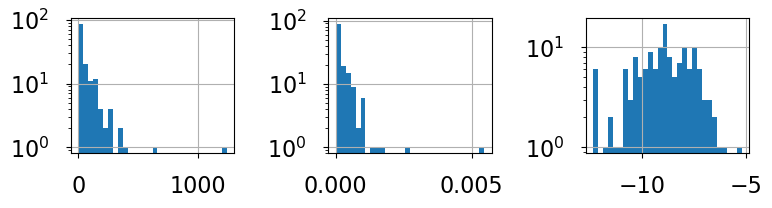

In [491]:
#plot distribution of data
plt.figure(figsize=(8, 6))

ax = plt.subplot(3,3,1)
# df_state['rate'].hist(bins=30)
df_state['observed'].hist(bins=30, log = True) ## looks like Poisson


ax = plt.subplot(3,3,2)
df_state['rate'].hist(bins=30, log = True) ## looks like Poisson


ax = plt.subplot(3,3,3)
np.log(df_state.rate).hist(bins=30, log = True)
plt.tight_layout()
plt.show()

# Poisson and negative binomial regression models -- statsmodel

## Pre-process data

In [103]:
del df_procss
df_procss = df_state.copy()

df_procss['season'] =  df_procss.season.astype('category') #convert to categorical variable
df_procss = pd.get_dummies(df_procss, columns=['season'])
df_procss[['obs_log', 'tas_log', 'dtr_log', 'RH_log']] = np.log(df_procss[['observedFilled', 'tas', 'dtr', 'RH']]) 
df_procss[['obs_lag1', 'tas_lag1', 'dtr_lag1', 'RH_lag1']] = np.log(df_procss[['observedFilled', 'tas', 'dtr', 'RH']]).shift(1) #lag1 
df_procss[['obs_lag2', 'tas_lag2', 'dtr_lag2', 'RH_lag2']] = np.log(df_procss[['observedFilled', 'tas', 'dtr', 'RH']]).shift(2) #lag2
# df_procss = df_procss.assign(intercept=1)

print(df_procss.shape)
# print(df_procss.dtypes)
df_procss.head()

(144, 29)


,date,year,observed,observedFilled,popn,tas,tasmax,tasmin,dtr,wet_bulb_temp,...,dtr_log,RH_log,obs_lag1,tas_lag1,dtr_lag1,RH_lag1,obs_lag2,tas_lag2,dtr_lag2,RH_lag2
0,2008-01-01,2008,5,5,217912.0,29.564121,34.538959,25.362134,9.176825,26.989253,...,2.216681,4.186767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2008-02-01,2008,17,17,217912.0,27.737060,31.666404,24.350523,7.315881,26.458439,...,1.990047,4.277712,1.609438,3.386561,2.216681,4.186767,NaN,NaN,NaN,NaN
2,2008-03-01,2008,8,8,217912.0,27.408592,32.590010,22.851544,9.738466,25.437677,...,2.276084,4.204844,2.833213,3.322769,1.990047,4.277712,1.609438,3.386561,2.216681,4.186767
3,2008-04-01,2008,4,4,219874.0,25.432973,33.474194,18.433622,15.040572,21.827340,...,2.710751,3.979473,2.079442,3.310857,2.276084,4.204844,2.833213,3.322769,1.990047,4.277712
4,2008-05-01,2008,2,2,219874.0,22.988088,31.551413,15.397581,16.153831,19.214945,...,2.782157,3.901061,1.386294,3.236046,2.710751,3.979473,2.079442,3.310857,2.276084,4.204844


In [104]:
## function to get model data

# del y, X, lst_fold_idx

def get_model_data(vars_interest):
    df_model = (df_procss[vars_interest]
                 .assign(intercept=1)
                # .insert(1,'intercept', 1)
                .dropna()
                .reset_index(drop=True)
               )
    print(df_model.shape)
    # print(df_model.head())
    
    ## get the index of the folds for one-step-ahead forecast
    dates_pred = df_model[df_model['year'] >= 2016].date
    dates_train = df_model[df_model['year'] < 2016].date
    fold_idx = df_model.index[df_model['year'] >= 2016].tolist()
    # print(lst_fold_idx) ## 95 to 142
    # print(len(lst_fold_idx) )
    
    y = df_model['observedFilled'] #dependent variable
    X = df_model.drop(['date','year', 'observedFilled'], axis = 1) # predictor df
    
    
    return y, X, fold_idx, dates_pred, dates_train

########################## baseline model  ################
# vars_interest = ['year', 'observedFilled', 'popn'] ## baseline (intercept only)

###------ vars for model1 types (non Cvs -------------------------
# vars_interest = ['year', 'observedFilled', 'popn', 'season_spring','season_summer', 'season_winter'] ## seasonal effect
# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag1'] ## observed lag1 effect
# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag2'] ## observed lag2 effect

###------ vars for model2 types (effect of Cvs -------------------------
# vars_interest = ['year', 'observedFilled', 'popn',  'tas_log',  'dtr_log', 'RH_log'] # Cvs
# vars_interest = ['year', 'observedFilled', 'popn',  'tas_lag1', 'dtr_lag1', 'RH_lag1'] #lag1 CVs
# vars_interest = ['year', 'observedFilled', 'popn',  'tas_lag2', 'dtr_lag2', 'RH_lag2'] #lag2 CVs
# vars_interest = ['year', 'observedFilled', 'popn',  'tas_log']
# vars_interest = ['year', 'observedFilled', 'popn',  'dtr_log']
# vars_interest = ['year', 'observedFilled', 'popn',  'RH_log']

###------ vars for model3  types (full models) -------------------------
# vars_interest = ['date','year', 'observedFilled', 'popn',  'obs_lag1', 'obs_lag2', 'season_spring','season_summer', 'season_winter','tas_log', 'dtr_log', 'RH_log']
vars_interest = ['date','year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2','season_spring','season_summer', 'season_winter', 'tas_lag1', 'dtr_lag1', 'RH_lag1']
# vars_interest = ['date','year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2','season_spring','season_summer', 'season_winter','tas_lag2', 'dtr_lag2', 'RH_lag2']
# vars_interest = ['date', 'year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2','season_spring','season_summer', 'season_winter', 
                 # 'tas_lag1', 'dtr_lag1', 'RH_lag1', 'tas_lag2', 'dtr_lag2', 'RH_lag2']

###------ vars for sub model  types (sub models depending on most accurate model2 type) -------------------------
# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2', 'season_spring','season_summer', 'season_winter', 'tas_log', 'dtr_log' ]
# vars_interest = ['date','year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2','season_spring','season_summer', 'season_winter', 'tas_log',  'RH_log']
# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2','season_spring','season_summer', 'season_winter',  'dtr_log', 'RH_log']
# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2','season_spring','season_summer', 'season_winter', 'tas_log']
# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2','season_spring','season_summer', 'season_winter',   'dtr_log' ]
# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2', 'season_spring','season_summer', 'season_winter', 'RH_log']


# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2', 'season_spring','season_summer', 'season_winter', 'tas_lag1', 'dtr_lag1']
# vars_interest = ['date', 'year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2','season_spring','season_summer', 'season_winter', 'tas_lag1', 'RH_lag1']
# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2','season_spring','season_summer', 'season_winter', 'dtr_lag1', 'RH_lag1']
# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2','season_spring','season_summer', 'season_winter', 'tas_lag1']
# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2','season_spring','season_summer', 'season_winter', 'dtr_lag1']
# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2','season_spring','season_summer', 'season_winter', 'RH_lag1']

# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2','season_spring','season_summer', 'season_winter', 
#                  'tas_lag1', 'dtr_lag1',  'tas_lag2', 'dtr_lag2']
# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2','season_spring','season_summer', 'season_winter', 
#                  'tas_lag1', 'RH_lag1',  'tas_lag2', 'RH_lag2']
# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2','season_spring','season_summer', 'season_winter', 
#                  'dtr_lag1', 'RH_lag1',  'dtr_lag2', 'RH_lag2']
# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2','season_spring','season_summer', 'season_winter', 
#                  'tas_lag1',  'tas_lag2' ]
# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2','season_spring','season_summer', 'season_winter', 
#                  'dtr_lag1',  'dtr_lag2' ]
# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2','season_spring','season_summer', 'season_winter', 
                 # 'RH_lag1',  'RH_lag2' ]

###------ Extra sub model  (sub model with lag1TAS + lag2TAS + lags of Obs + season) -------------------------  
# vars_interest = ['year', 'observedFilled', 'popn', 'obs_lag1', 'obs_lag2', 'season_spring','season_summer', 'season_winter', 'tas_lag1','tas_lag2']



y, X, lst_fold_idx, dates_pred, dates_train = get_model_data(vars_interest)
print([y.shape, X.shape])
print(y[0:5]) 
print(lst_fold_idx)
dates_pred
dates_train
X

(142, 13)
[(142,), (142, 10)]
0    8
1    4
2    2
3    1
4    4
Name: observedFilled, dtype: int64
[94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141]


,popn,obs_lag1,obs_lag2,season_spring,season_summer,season_winter,tas_lag1,dtr_lag1,RH_lag1,intercept
0,217912.0,2.833213,1.609438,0,0,0,3.322769,1.990047,4.277712,1
1,219874.0,2.079442,2.833213,0,0,0,3.310857,2.276084,4.204844,1
2,219874.0,1.386294,2.079442,0,0,0,3.236046,2.710751,3.979473,1
3,219874.0,0.693147,1.386294,0,0,1,3.134976,2.782157,3.901061,1
4,221464.0,0.000000,0.693147,0,0,1,3.084334,2.679625,4.025852,1
...,...,...,...,...,...,...,...,...,...,...
137,246677.0,4.962845,4.955827,0,0,1,3.067172,2.788740,3.939324,1
138,246677.0,5.043425,4.962845,1,0,0,3.098711,2.788339,3.828975,1
139,246213.0,4.859812,5.043425,1,0,0,3.214774,2.812821,3.916582,1
140,246213.0,4.356709,4.859812,1,0,0,3.343149,2.709303,3.944237,1


### Fit a  negative binomial model to training data

In [216]:
# # del X_train
# predictors = X.columns.drop('popn')
# split_train = lst_fold_idx[0]
# y_train = y[:split_train];  ## 
# X_train =  X[:split_train] ##X_trans.head(split_train)
# # X_train[[predictors]]
# X_train.drop('popn', axis = 1)
# lst_fold_idx

In [38]:
###################################
## Fit a NB model 
## First choose the overdispersion parameter using the discrete_model API; alpha 
###############################

# del alpha, y_pred_train_nb

def get_alpha(lst_fold_idx, y, X):
    
    split_train = lst_fold_idx[0]
    y_train = y[:split_train];  ## 
    X_train =  X[:split_train] ##X_trans.head(split_train)
    

    nb_modl_train = dm.NegativeBinomial(
        y_train,
    # X_train[['intercept', 'log_obs_lag1', 'log_obs_lag2','season_spring','season_summer', 'season_winter','log_tas','log_dtr', 'log_RH']], ## exclude 'season_autumn',
    # X_train[['intercept', 'log_obs_lag1', 'log_obs_lag2','season_spring','season_summer', 'season_winter', 'log_tas_lag2','log_dtr_lag2', 'log_RH_lag2']],
        X_train.drop('popn', axis = 1),
        offset=np.log(X_train['popn']),
    )

    nb_res_train = nb_modl_train.fit(maxiter = 60)

    print(nb_res_train.params['alpha'].round(7))
    # print(nb_res_train.summary())   ## this gives alpha = 0.2771 and is significant at 95% CI


###########################
## now fit negative binomial model using GLM model
#######################
##alpha =  0.2847  ##0.6396 (lag2) #0.2847 (lag1) ## 0.2771(no lag) ## lags indicate for climate variables (for NSW)
    alpha =   nb_res_train.params['alpha'].round(7) #0.2670
    # print(alpha)
    nb_modl_train_glm = sm.GLM(
        y_train,
    # X_train[['intercept', 'log_obs_lag1', 'season_spring','season_summer', 'season_winter','log_tas','log_dtr', 'log_RH']],
    # X_train[['intercept', 'log_obs_lag1', 'log_obs_lag2','season_spring','season_summer', 'season_winter','log_tas', 'log_dtr', 'log_RH']],
    # X_train[['intercept', 'log_obs_lag1', 'log_obs_lag2', 'season_spring','season_summer', 'season_winter', 'log_tas_lag2','log_dtr_lag2', 'log_RH_lag2']],
        X_train.drop('popn', axis = 1),
        offset=np.log(X_train['popn']),
        family=sm.families.NegativeBinomial(alpha=alpha),
    )
    res_nb_modl_train_glm = nb_modl_train_glm.fit()
    print(res_nb_modl_train_glm.summary())  
    print(res_nb_modl_train_glm.params['intercept'].round(7))
    print(res_nb_modl_train_glm.bse['intercept'].round(7))

#####
# get predictions on linear scale (the rate)
########
# y_pred_train = res.predict(X_train[['intercept', 'obs_lag1', 'season_spring','season_summer', 'season_winter','tas','dtr', 'RH']])
# y_pred_train_nb = res_nb_modl_train_glm.predict(X_train[['intercept', 'log_obs_lag1', 'log_obs_lag2','season_spring','season_summer', 'season_winter','log_tas', 'log_dtr', 'log_RH']])
# y_pred_train_nb = res_nb_modl_train_glm.predict(X_train[['intercept', 'log_obs_lag1', 'log_obs_lag2', 'season_spring','season_summer', 'season_winter', 'log_tas_lag2','log_dtr_lag2', 'log_RH_lag2']])
    y_pred_train_nb = res_nb_modl_train_glm.predict(X_train.drop('popn', axis =1))
    y_rate_train_nb = y_train/X_train['popn']
    
    return alpha, y_pred_train_nb
##############################################


#####################################################
alpha, y_pred_train_nb = get_alpha(lst_fold_idx, y, X)
print(alpha)
# y_pred_train_nb

Optimization terminated successfully.
         Current function value: 6.078085
         Iterations: 46
         Function evaluations: 50
         Gradient evaluations: 50
0.3646992
                 Generalized Linear Model Regression Results                  
Dep. Variable:         observedFilled   No. Observations:                   94
Model:                            GLM   Df Residuals:                       85
Model Family:        NegativeBinomial   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -571.34
Date:                Fri, 21 Feb 2025   Deviance:                       99.202
Time:                        09:58:34   Pearson chi2:                     125.
No. Iterations:                    13   Pseudo R-squ. (CS):             0.9978
Covariance Type:            nonrobust                                         
                    coef    

In [105]:
## dictionary to hold results 
alpha_all = dict()
deviance_all = dict()
mae_all = dict()
rmse_all = dict()
y_pred_all = dict()

intercept_all = dict()
obs_lag1_all = dict()
obs_lag2_all = dict()

tas_all = dict()
dtr_all = dict()
RH_all = dict()

tas_lag1_all = dict()
dtr_lag1_all = dict()
RH_lag1_all = dict()

tas_lag2_all = dict()
dtr_lag2_all = dict()
RH_lag2_all = dict()

season_spring_all = dict()
season_summer_all = dict()
season_winter_all = dict()

std_intercept_all = dict()
std_obs_lag1_all = dict()
std_obs_lag2_all = dict()

std_tas_all = dict()
std_dtr_all = dict()
std_RH_all = dict()

std_tas_lag1_all = dict()
std_dtr_lag1_all = dict()
std_RH_lag1_all = dict()

std_tas_lag2_all = dict()
std_dtr_lag2_all = dict()
std_RH_lag2_all = dict()

std_season_spring_all = dict()
std_season_summer_all = dict()
std_season_winter_all = dict()

for split in lst_fold_idx:
    
    alpha_all[split]= 0.0000000
    deviance_all[split] = 0.0000000
    mae_all[split] = 0.0000000
    rmse_all[split] = 0.0000000
    y_pred_all[split] = 0.000000000
    
    intercept_all[split] = 0.000000000
    obs_lag1_all[split] = 0.000000000
    obs_lag2_all[split] = 0.000000000
    
    tas_all[split] = 0.000000000
    dtr_all[split] = 0.000000000
    RH_all[split] = 0.000000000
    
    tas_lag1_all[split] = 0.000000000
    dtr_lag1_all[split] = 0.000000000
    RH_lag1_all[split] = 0.000000000
    
    tas_lag2_all[split] = 0.000000000
    dtr_lag2_all[split] = 0.000000000
    RH_lag2_all[split] = 0.000000000
    
    season_spring_all[split] = 0.000000000
    season_summer_all[split] = 0.000000000
    season_winter_all[split] = 0.000000000
    
    std_intercept_all[split] = 0.000000000
    std_obs_lag1_all[split] = 0.000000000
    std_obs_lag2_all[split] = 0.000000000
    
    std_tas_all[split] = 0.000000000
    std_dtr_all[split] = 0.000000000
    std_RH_all[split] = 0.000000000

    std_tas_lag1_all[split] = 0.000000000
    std_dtr_lag1_all[split] = 0.000000000
    std_RH_lag1_all[split] = 0.000000000

    std_tas_lag2_all[split] = 0.000000000
    std_dtr_lag2_all[split] = 0.000000000
    std_RH_lag2_all[split] = 0.000000000

    std_season_spring_all[split] = 0.000000000
    std_season_summer_all[split] = 0.000000000
    std_season_winter_all[split] = 0.000000000
    

In [937]:
np.mean(list(mae_all.values())).round(8)

0.0

In [106]:
##############################
## fit Model  -- intercept + lag1 + sesons+tas + dtr + RH 
#############################


for split in lst_fold_idx: ##[:-1]: [0:5]

    y_train_fold = y[:split];
    X_train_fold = X[:split] ###X_trans[:split]
    idx = lst_fold_idx[0]
    
    if y_train_fold.shape[0]> idx: ##94:   ## 96 => for no lag; 95 => for  lag1; 94 => for  lag2
            y_train_fold = y_train_fold.tail(idx) #use slideing window for training set (ie; drop 1st row if training sample is >95
            X_train_fold = X_train_fold.tail(idx)
    else: 
        y_train_fold = y_train_fold
        X_train_fold = X_train_fold
    
    y_test_fold =  y[split]  ## y[split:].head(1)   ## one-step ahead
    X_test_fold = X[split:].head(1) ##X_trans[split:].head(1) ###
    
    y_rate   = y_test_fold/X_test_fold['popn'] ## rate is required to compute error as predict() gives predictions on linear scale
    # print(y_train_fold.tail(1))
    # print(y_test_fold)
    # print(X_test_fold)
    # print(y_rate_fold)
    # print(y_train_fold.shape[0])
       
    ###########################
## fit Poisson model using GLM model
#######################

    # modl = sm.GLM(
    #     y_train_fold,
    #     # X_train_fold[['intercept', 'log_obs_lag1', 'season_spring','season_summer', 'season_winter','tas','dtr', 'RH']], ## exclude 'season_autumn'
    #      X_train_fold[['intercept', 'log_obs_lag1', 'log_obs_lag2','season_spring','season_summer', 'season_winter','log_tas', 'log_dtr', 'log_RH']],
    #     offset=np.log(X_train_fold['popn']),
    #     family=sm.families.Poisson(),
    # )
    # res = modl.fit()
    # ###print(res.summary())   ## 
    
    ###########################
## get alpha for NB model using dm pkg
#######################
    nb_modl_train = dm.NegativeBinomial(
        y_train_fold,
    # X_train[['intercept', 'log_obs_lag1', 'log_obs_lag2','season_spring','season_summer', 'season_winter','log_tas','log_dtr', 'log_RH']], ## exclude 'season_autumn',
    # X_train[['intercept', 'log_obs_lag1', 'log_obs_lag2','season_spring','season_summer', 'season_winter', 'log_tas_lag2','log_dtr_lag2', 'log_RH_lag2']],
        X_train_fold.drop('popn', axis = 1),
        offset=np.log(X_train_fold['popn']),
    )

    res_train = nb_modl_train.fit(maxiter = 100)
    alpha = res_train.params['alpha'].round(7)
    # print(res_train.params['alpha'].round(7))
    print(alpha)
    
###########################
## fit negative binomial model using GLM model
#######################
    alpha =  alpha ## nb_res_train.params['alpha'].round(7) ##0.2670  ## 0.6396 #0.2847 #0.2787 #30.2771   ##this was chosen based on fitting model to training data 
    # print(alpha)
    modl = sm.GLM(
    y_train_fold,
    # X_train_fold[['intercept', 'log_obs_lag1', 'log_obs_lag2','season_spring','season_summer', 'season_winter','log_tas', 'log_dtr', 'log_RH']],
    # X_train_fold[['intercept', 'log_obs_lag1', 'log_obs_lag2','season_spring','season_summer', 'season_winter', 'log_tas_lag2', 'log_dtr_lag2', 'log_RH_lag2']],
    X_train_fold.drop('popn', axis =1),
    offset=np.log(X_train_fold['popn']),
    family=sm.families.NegativeBinomial(alpha=alpha),
        )
    res = modl.fit()
    # # print(res.summary())  
########################################

# # ## get one-step ahead prediction
    # y_pred  = res.predict(X_test_fold[['intercept', 'log_obs_lag1', 'season_spring','season_summer', 'season_winter','tas','dtr', 'RH']])
    # y_pred  = res.predict(X_test_fold[['intercept', 'log_obs_lag1', 'log_obs_lag2','season_spring','season_summer', 'season_winter','log_tas', 'log_dtr', 'log_RH']])
    # y_pred  = res.predict(X_test_fold[['intercept', 'log_obs_lag1', 'log_obs_lag2','season_spring','season_summer', 'season_winter', 'log_tas_lag2', 'log_dtr_lag2', 'log_RH_lag2']]),
    y_pred  = res.predict(X_test_fold.drop('popn', axis =1)),
    rmse = np.sqrt(mean_squared_error(y_rate , y_pred )).round(7) #RMSE of test set
    mae  = mean_absolute_error(y_rate , y_pred ).round(7) #MAE of test set  
# #     deviance  = res.deviance.round(7) 
# # # # # # deviance1 = poisson_cv.score_.round(4)

    # print("deviance: {}".format(res.deviance.round(7)))
    # # print("RMSE: {}".format(rmse))
    # # print("MAE: {}".format(mae))
    # print("y_pred: {}", y_pred[0].values[0].round(7))
    
###### store result in dictionaries 
    alpha_all[split] = alpha
    deviance_all[split] =  res.deviance.round(7) 
    mae_all[split] = mae 
    rmse_all[split] = rmse 
    y_pred_all[split] = y_pred[0].values[0].round(7)  ##y_pred.values[0].round(7)
    
    intercept_all[split] = res.params['intercept'].round(7)
    obs_lag1_all[split] = res.params['obs_lag1'].round(7)
    obs_lag2_all[split] = res.params['obs_lag2'].round(7)
    
    # tas_all[split] = res.params['tas_log'].round(7)
    # dtr_all[split] = res.params['dtr_log'].round(7)
    # RH_all[split] = res.params['RH_log'].round(7)
    
    tas_lag1_all[split] = res.params['tas_lag1'].round(7)
    dtr_lag1_all[split] = res.params['dtr_lag1'].round(7)
    RH_lag1_all[split] = res.params['RH_lag1'].round(7)
    
    # tas_lag2_all[split] = res.params['tas_lag2'].round(7)
    # dtr_lag2_all[split] = res.params['dtr_lag2'].round(7)
    # RH_lag2_all[split] = res.params['RH_lag2'].round(7)
    
    season_spring_all[split] = res.params['season_spring'].round(7)
    season_summer_all[split] = res.params['season_summer'].round(7)
    season_winter_all[split] = res.params['season_winter'].round(7)
    
    std_intercept_all[split] = res.bse['intercept'].round(7)
    std_obs_lag1_all[split] = res.bse['obs_lag1'].round(7)
    std_obs_lag2_all[split] = res.bse['obs_lag2'].round(7)
    
    # std_tas_all[split] = res.bse['tas_log'].round(7)
    # std_dtr_all[split] = res.bse['dtr_log'].round(7)
    # std_RH_all[split] = res.bse['RH_log'].round(7)

    std_tas_lag1_all[split] = res.bse['tas_lag1'].round(7)
    std_dtr_lag1_all[split] = res.bse['dtr_lag1'].round(7)
    std_RH_lag1_all[split] = res.bse['RH_lag1'].round(7)

    # std_tas_lag2_all[split] = res.bse['tas_lag2'].round(7)
    # std_dtr_lag2_all[split] = res.bse['tas_lag2'].round(7)
    # std_RH_lag2_all[split] = res.bse['tas_lag2'].round(7)

    std_season_spring_all[split] = res.bse['season_spring'].round(7)
    std_season_summer_all[split] = res.bse['season_summer'].round(7)
    std_season_winter_all[split] = res.bse['season_winter'].round(7)
    
    
### GET average MAE from all folds
mae = np.mean(list(mae_all.values())).round(8)
print('mae:', mae)
print('alpha:', np.mean(list(alpha_all.values())).round(4))  ## get mean of mae from all folds
print(np.mean(list(std_intercept_all.values())).round(8))


Optimization terminated successfully.
         Current function value: 4.510693
         Iterations: 48
         Function evaluations: 52
         Gradient evaluations: 52
0.657286
Optimization terminated successfully.
         Current function value: 4.520488
         Iterations: 48
         Function evaluations: 53
         Gradient evaluations: 53
0.6494188
Optimization terminated successfully.
         Current function value: 4.531576
         Iterations: 48
         Function evaluations: 53
         Gradient evaluations: 53
0.6418123
Optimization terminated successfully.
         Current function value: 4.537430
         Iterations: 48
         Function evaluations: 53
         Gradient evaluations: 53
0.6273696
Optimization terminated successfully.
         Current function value: 4.548751
         Iterations: 49
         Function evaluations: 54
         Gradient evaluations: 54
0.6064614
Optimization terminated successfully.
         Current function value: 4.563551
         It

In [16]:
print(np.mean(list(std_intercept_all.values())).round(8))
print(np.mean(list(intercept_all.values())).round(8))

7.00188852
-12.48169893


## compare performance with baseline model
- Ref: https://people.duke.edu/~rnau/compare.htm
- Mean Absolute Scaled Error (MASE):  is another relative measure of error that is applicable only to time series data. 
- It is defined as the MAE of the model divided by the MAE of a naive model
- It measures the relative reduction in error compared to a naive model.  Ideally its value will be significantly less than 1.

In [929]:
# mae_baseline = (nsw; 0.00062152)(qld; 0.00050686) (vic;0.00037509) (sa; 0.000670080) (tas; 0.0002696)(wa; 0.00026105) (nt; 0.00031728) 0.00062152
mae_baseline = 0.00026105

mase = round(100*(mae /mae_baseline), 2)
mase 

64.97

## Compute Average of Coefficients and their Std deviations  

In [71]:
print('Intercept:')
print(' mean:', np.mean(list(intercept_all.values())).round(4), 'std err:', np.mean(list(std_intercept_all.values())).round(4),
  'CI:', [np.mean(list(intercept_all.values())).round(4)- 1.96 *  np.mean(list(std_intercept_all.values())).round(4), np.mean(list(intercept_all.values())).round(4)+ 1.96 *  np.mean(list(std_intercept_all.values())).round(4)]
     )

print('obs_lag1:')
print(' mean:', np.mean(list(obs_lag1_all.values())).round(4), 'std err:', np.mean(list(std_obs_lag1_all.values())).round(4),
  'CI:', [np.mean(list(obs_lag1_all.values())).round(4)- 1.96 *  np.mean(list(std_obs_lag1_all.values())).round(4), np.mean(list(obs_lag1_all.values())).round(4)+ 1.96 *  np.mean(list(std_obs_lag1_all.values())).round(4)]
     )
print('obs_lag2:')
print(' mean:', np.mean(list(obs_lag2_all.values())).round(4), 'std err:', np.mean(list(std_obs_lag2_all.values())).round(4),
  'CI:', [np.mean(list(obs_lag2_all.values())).round(4)- 1.96 *  np.mean(list(std_obs_lag2_all.values())).round(4), np.mean(list(obs_lag2_all.values())).round(4)+ 1.96 *  np.mean(list(std_obs_lag2_all.values())).round(4)]
     )
# print('tas:')
# print(' mean:', np.mean(list(tas_all.values())).round(4), 'std err:', np.mean(list(std_tas_all.values())).round(4))
# # print('dtr:')
# # print(' mean:', np.mean(list(dtr_all.values())).round(4), 'std err:', np.mean(list(std_dtr_all.values())).round(4))
# print('RH:')
# print(' mean:', np.mean(list(RH_all.values())).round(4), 'std err:', np.mean(list(std_RH_all.values())).round(4))

print('tas_lag1:')
print(' mean:', np.mean(list(tas_lag1_all.values())).round(4), 'std err:', np.mean(list(std_tas_lag1_all.values())).round(4),
  'CI:', [np.mean(list(tas_lag1_all.values())).round(4)- 1.96 *  np.mean(list(std_tas_lag1_all.values())).round(4), np.mean(list(tas_lag1_all.values())).round(4)+ 1.96 *  np.mean(list(std_tas_lag1_all.values())).round(4)]
     )
print('dtr_lag1:')
print(' mean:', np.mean(list(dtr_lag1_all.values())).round(4), 'std err:', np.mean(list(std_dtr_lag1_all.values())).round(4),
  'CI:', [np.mean(list(dtr_lag1_all.values())).round(4)- 1.96 *  np.mean(list(std_dtr_lag1_all.values())).round(4), np.mean(list(dtr_lag1_all.values())).round(4)+ 1.96 *  np.mean(list(std_dtr_lag1_all.values())).round(4)]
     )
print('RH_lag1:')
print(' mean:', np.mean(list(RH_lag1_all.values())).round(4), 'std err:', np.mean(list(std_RH_lag1_all.values())).round(4),
  'CI:', [np.mean(list(RH_lag1_all.values())).round(4)- 1.96 *  np.mean(list(std_RH_lag1_all.values())).round(4), np.mean(list(RH_lag1_all.values())).round(4)+ 1.96 *  np.mean(list(std_RH_lag1_all.values())).round(4)]
     )
# print('tas_lag2:')
# print(' mean:', np.mean(list(tas_lag2_all.values())).round(4), 'std err:', np.mean(list(std_tas_lag2_all.values())).round(4))
# print('dtr_lag2:')
# print(' mean:', np.mean(list(dtr_lag2_all.values())).round(4), 'std err:', np.mean(list(std_dtr_lag2_all.values())).round(4))
# print('RH_lag2:')
# print(' mean:', np.mean(list(RH_lag2_all.values())).round(4), 'std err:', np.mean(list(std_RH_lag2_all.values())).round(4))

print('season_spring_all:')
print(' mean:', np.mean(list(season_spring_all.values())).round(4), 'std err:', np.mean(list(std_season_spring_all.values())).round(4),
  'CI:', [np.mean(list(season_spring_all.values())).round(4)- 1.96 *  np.mean(list(std_season_spring_all.values())).round(4), np.mean(list(season_spring_all.values())).round(4)+ 1.96 *  np.mean(list(std_season_spring_all.values())).round(4)]
     )
print('season_spring_all:')
print(' mean:', np.mean(list(season_summer_all.values())).round(4), 'std err:', np.mean(list(std_season_summer_all.values())).round(4),
  'CI:', [np.mean(list(season_summer_all.values())).round(4)- 1.96 *  np.mean(list(std_season_summer_all.values())).round(4), np.mean(list(season_summer_all.values())).round(4)+ 1.96 *  np.mean(list(std_season_summer_all.values())).round(4)]
     )
print('season_spring_all:')
print(' mean:', np.mean(list(season_winter_all.values())).round(4), 'std err:', np.mean(list(season_winter_all.values())).round(4),
  'CI:', [np.mean(list(season_winter_all.values())).round(4)- 1.96 *  np.mean(list(std_season_winter_all.values())).round(4), np.mean(list(season_winter_all.values())).round(4)+ 1.96 *  np.mean(list(std_season_winter_all.values())).round(4)]
     )


Intercept:
 mean: -2.8535 std err: 7.4925 CI: [-17.5388, 11.8318]
obs_lag1:
 mean: 1.0587 std err: 0.0925 CI: [0.8774, 1.24]
obs_lag2:
 mean: -0.4076 std err: 0.0859 CI: [-0.575964, -0.239236]
tas_lag1:
 mean: -1.1496 std err: 0.6851 CI: [-2.4923960000000003, 0.19319600000000015]
dtr_lag1:
 mean: -0.3935 std err: 0.7346 CI: [-1.833316, 1.046316]
RH_lag1:
 mean: -1.2621 std err: 1.2851 CI: [-3.7808959999999994, 1.2566959999999996]
season_spring_all:
 mean: -0.2536 std err: 0.2696 CI: [-0.782016, 0.274816]
season_spring_all:
 mean: -0.1963 std err: 0.1897 CI: [-0.5681120000000001, 0.17551200000000003]
season_spring_all:
 mean: 0.3307 std err: 0.3307 CI: [-0.2269199999999999, 0.8883199999999999]


## Compute 95% CI's for the coefficients  

In [107]:
df_means = pd.DataFrame([intercept_all, obs_lag1_all, obs_lag2_all,  tas_lag1_all, dtr_lag1_all, RH_lag1_all, season_spring_all, season_summer_all, season_winter_all])
df_means = df_means.rename(index={0: 'intercept', 1: 'obs_lag1', 2: 'obs_lag2', 3: 'tas_lag1', 4: 'dtr_lag1', 5: 'RH_lag1', 6: 'season_spring', 7: 'season_summer',8: 'season_winter'})
df_means = df_means.rename_axis('coeff').reset_index() 
df_means['mean'] = df_means.mean(axis = 1) #compute row means 
df_means = df_means[['coeff', 'mean']]
df_means

df_stderr = pd.DataFrame([std_intercept_all, std_obs_lag1_all, std_obs_lag2_all,  std_tas_lag1_all, std_dtr_lag1_all, std_RH_lag1_all, std_season_spring_all, std_season_summer_all, std_season_winter_all])
df_stderr = df_stderr.rename(index={0: 'intercept', 1: 'obs_lag1', 2: 'obs_lag2', 3: 'tas_lag1', 4: 'dtr_lag1', 5: 'RH_lag1', 6: 'season_spring', 7: 'season_summer',8: 'season_winter'})
df_stderr = df_stderr.rename_axis('coeff').reset_index() 
df_stderr['stderr'] = df_stderr.mean(axis = 1) #compute row means 
df_stderr = df_stderr[['coeff', 'stderr']]
df_stderr

df_coeff = df_means
df_coeff['stderr'] = df_stderr['stderr']
df_coeff['lower'] = df_coeff['mean'] - 1.96* df_coeff['stderr']
df_coeff['upper'] = df_coeff['mean'] +1.96* df_coeff['stderr']
df_coeff
# intercept_means = {"NSW": -12.4817, "QLD": -16.1151, "VIC": -2.9321, "SA": -2.835, "TAS": 0.00, "WA": 0.00, 'NT': 0.00 }
# intercept_std_err = {"NSW": 7.0, "QLD": -16.1151, "VIC": -2.9321, "SA": -2.835, "TAS": 0.00, "WA": 0.00, 'NT': 0.00 }
# intercept_means 

,coeff,mean,stderr,lower,upper
0,intercept,-16.703848,11.584475,-39.409420,6.001723
1,obs_lag1,0.780861,0.095768,0.593156,0.968567
2,obs_lag2,-0.306348,0.090537,-0.483801,-0.128894
3,tas_lag1,-1.353689,1.273640,-3.850024,1.142646
4,dtr_lag1,1.053421,1.062307,-1.028701,3.135542
5,RH_lag1,1.963930,1.945400,-1.849054,5.776914
6,season_spring,0.186275,0.322782,-0.446378,0.818928
7,season_summer,0.351377,0.232905,-0.105116,0.807870
8,season_winter,0.155167,0.341122,-0.513432,0.823766


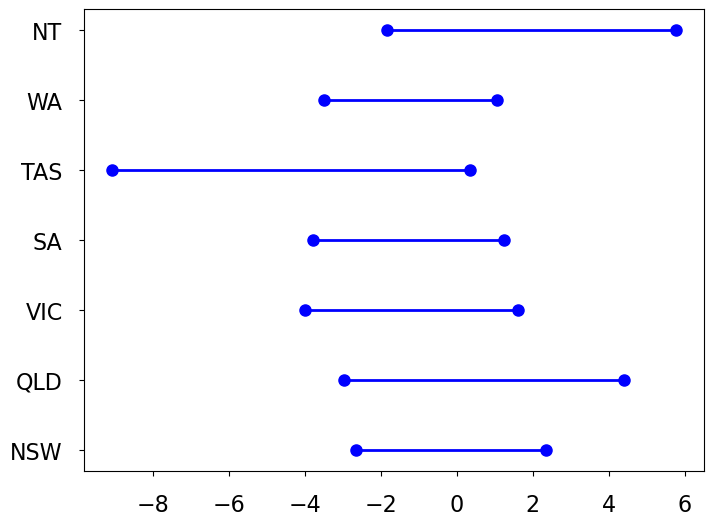

In [120]:
# intercept_ci = {}
# intercept_ci['region'] = ['NSW','QLD',    'VIC',    'SA',      'TAS',  'WA',    'NT']
# intercept_ci['mean'] = [-12.48,  -16.11,   -2.93,   -2.85,     12.19,  -2.44,    -16.70]
# intercept_ci['lower'] = [-26.20,  -35.77,  -17.99,   -17.53,   -11.53,  -16.13,   -39.40]
# intercept_ci['upper'] = [1.24,    3.54,     12.12,   11.83,    35.92,   11.25,   6.00]
# df_intercept = pd.DataFrame(intercept_ci)

# tas_ci = {}
# tas_ci['region'] = ['NSW','QLD',    'VIC',    'SA',    'TAS',  'WA',    'NT']
# tas_ci['mean'] = [-0.98,  -0.73,   -2.03,   -1.14,     -1.08,  -1.21,    -1.35]
# tas_ci['lower'] = [-1.86,  -1.86,  -3.13,   -2.49,   -2.33,  -2.33,   -3.85]
# tas_ci['upper'] = [0.10,   0.40,   -0.93,   0.19,    0.16,   -0.10,   1.14]
# df_tas  = pd.DataFrame(tas_ci)


# dtr_ci = {}
# dtr_ci['region'] = ['NSW','QLD',    'VIC',    'SA',    'TAS',  'WA',    'NT']
# dtr_ci['mean'] = [0.75,  0.75,   0.03,       -0.39,     -1.22,  -0.77,    1.05]
# dtr_ci['lower'] = [-0.93,  -0.94,  -1.32,   -1.833,     -3.13,  -2.23,   -1.02]
# dtr_ci['upper'] = [2.44,   2.45,  1.38,    1.04,       0.68,   0.68,   3.13]
# df_dtr  = pd.DataFrame(dtr_ci)

rh_ci = {}
rh_ci['region'] = ['NSW','QLD',    'VIC',    'SA',    'TAS',  'WA',    'NT']
rh_ci['mean'] = [-0.15,  0.70,   -1.19,      -1.26,    -4.36,  -1.23,    1.96]
rh_ci['lower'] = [-2.65,  -2.98,  -4.01,   -3.78,     -9.07,  -3.51,   -1.84]
rh_ci['upper'] = [2.34,   4.39,  1.62,    1.25,       0.35,   1.05,   5.77]
df_rh  = pd.DataFrame(rh_ci)

plt.figure(figsize=(8, 6))
for lower,upper,y in zip(df_rh['lower'],df_rh['upper'],range(len(df_rh))):
    plt.plot((lower,upper),(y,y),'ro-',color='blue')
plt.yticks(range(len(df_rh)),list(df_rh['region']))
plt.show()

# df_rh


In [ ]:
obs_lag1_ci = {}
obs_lag1_ci['region'] = ['NSW','QLD','VIC', 'SA', 'TAS', 'WA', 'NT']
obs_lag1_ci['mean'] = [0.0,    0.0,   0.0,   1.058653,  0.0,  0.0,  0.0]
obs_lag1_ci['lower'] = [0.0,    0.0,  0.0,   0.877385,  0.0,  0.0,  0.0]
obs_lag1_ci['upper'] = [0.0,   0.0,   0.0,   1.239922,   0.0, 0.0,  0.0]
obs_lag1_ci = pd.DataFrame(obs_lag1_ci)

obs_lag1_ci

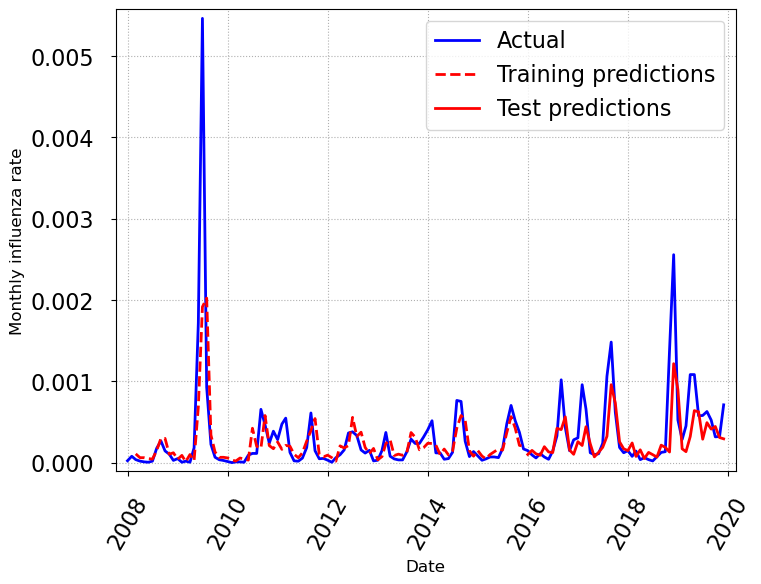

In [940]:
## plot obs Pred
dates = df_procss['date']
dates
dates_pred = dates_pred ##df_procss[df_procss['year'] >= 2016].date
dates_train = dates_train ## df_procss[df_procss['year'] < 2016].date
y_preds = list(y_pred_all.values())

###plot figure
plt.figure(figsize=(8, 6))
# plt.plot(dates, df_procss['rate'], 'b', label = 'Actual')
plt.plot(dates, df_procss['observed']/df_procss['popn'], 'b', label = 'Actual')
plt.plot(dates_train, y_pred_train_nb, '--r', label = 'Training predictions')

plt.plot(dates_pred, y_preds, 'r', label = 'Test predictions') 
plt.legend()
plt.grid(linestyle=':')
plt.ylabel("Monthly influenza rate", fontsize=12) 
plt.xlabel("Date", fontsize=12) 
plt.xticks(rotation= 60) #'vertical'
plt.margins(0.02)
#     # #plt.savefig(path + '/Results/AbstractPlots/papers_trend_plot.pdf', dpi=300,bbox_inches='tight');
plt.show()

In [847]:
max(list(intercept_all.values()))

-0.1825142

 -13.653684033333334


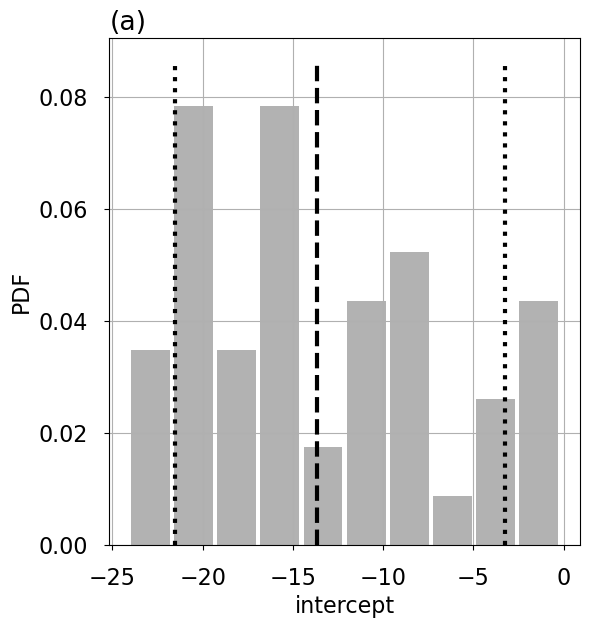

In [852]:
## Plot pdf of coefficients and standard errors

# data_mean_all = np.mean(data_mean)
# data_var_all = np.var(data_mean)



fig = plt.figure()

density=True

plt.subplot(5,4,1)
# ymax=max(list(intercept_all.values()))
plot_hist(list(intercept_all.values()), None, 'k', None, density, '')
plt.title('(a)', loc='left'); 
plt.xlabel('intercept')
plt.ylabel('PDF'); 
# plt.ylim(0,ymax); plt.xlim(0,4.5)
 

# plt.subplot(5,4,3); 
# ymax=35
# plot_hist(intercept_BS, None, 'k', ymax, density, '')
# plt.title('(c)', loc='left'); 
# plt.xlabel('intercept')
# plt.ylabel('PDF'); plt.ylim(0,ymax); plt.xlim(-0.05,0.05)
# plt.grid()

# plt.subplot(5,4,4); 
# ymax=6.0
# plt.title('(d)', loc='left'); 
# plot_hist(r_value_BS, None, 'k', ymax, density, '')
# plt.xlabel('correlation coefficient')
# plt.ylabel('PDF'); plt.ylim(0,ymax); plt.xlim(0.0,1.0)

plt.grid()

plt.tight_layout()

## Save result 

In [ ]:
res = pd.DataFrame([y_pred_all, deviance_all, mae_all, rmse_all, intercept_all, obs_lag_all, season_spring_all, season_summer_all, season_winter_all, tas_all, dtr_all, RH_all])
res = res.rename(index={0: 'y_pred', 1: 'deviance', 2: 'mae', 3: 'rmse', 4: 'intercept', 5: 'obs_lag1', 6: 'season_spring', 7: 'season_summer',
                                8: 'season_winter', 9: 'tas', 10: 'dtr', 11: 'RH'})
res = res.rename_axis('result').reset_index()  
# res.to_csv(path + 'results/infl_paper/nt_poiss.csv', index = False)
res.to_csv(path + 'results/infl_paper/nt_nb.csv', index = False)
res

In [801]:
# del y_preds
dates_train
y_pred_train_nb

0     0.000009
1     0.000012
2     0.000010
3     0.000048
4     0.000027
        ...   
89    0.001064
90    0.000701
91    0.000369
92    0.000046
93    0.000022
Length: 94, dtype: float64

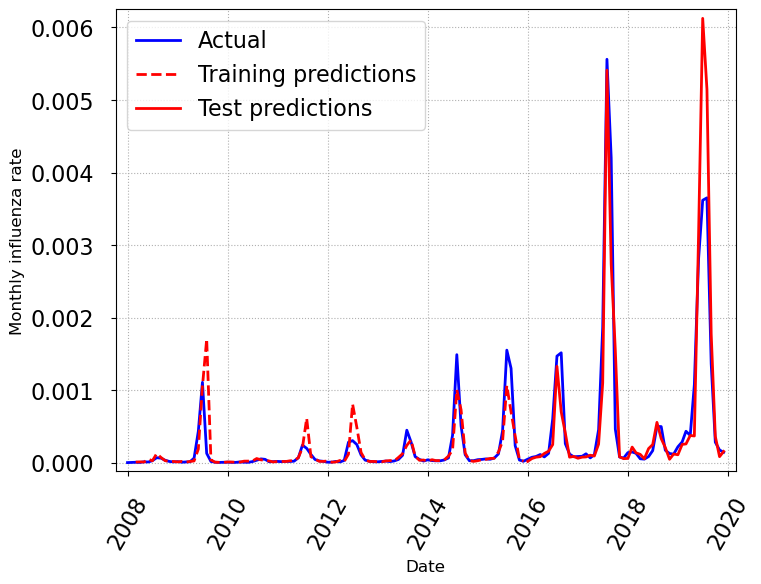

### Some helpful functions

In [9]:
def score_estimator(estimator, y_test, X_test):
    """Score an estimator on the test set."""
    y_pred = estimator.predict(X_test)

    print(
        "MSE: %.35f"
        % mean_squared_error(
            y_test, y_pred
        ) ##, sample_weight=df_state["popn"]
    )
    print(
        "MAE: %.35f"
        % mean_absolute_error(
            y_test, y_pred
        ) ## , sample_weight=df_state["popn"]
    )

    # Ignore non-positive predictions, as they are invalid for
    # the Poisson deviance.
    mask = y_pred > 0
    if (~mask).any():
        n_masked, n_samples = (~mask).sum(), mask.shape[0]
        print(
            "WARNING: Estimator yields invalid, non-positive predictions "
            f" for {n_masked} samples out of {n_samples}. These predictions "
            "are ignored when computing the Poisson deviance."
        )

    print(
        "mean Poisson deviance: %.5f"
        % mean_poisson_deviance(
            y_test[mask],
            y_pred[mask]
        ) #,sample_weight=df_state["popn"][mask],
    )


######## function to plot observed vs predicted error
def plot_pred(dates, y, y_pred, split): 

    dates_pred = dates[split:] # 
    # print(type(dates), dates.shape, dates_pred.shape, y_pred.shape)  #pandas series  208

    #plot figure
    plt.figure(figsize=(8, 6))
    plt.plot(dates, y, 'b', label = 'Actual')
    plt.plot(dates_pred, y_pred, 'r', label = 'Predicted') #use this for others
    plt.legend()
    plt.grid(linestyle=':')
    plt.ylabel("Monthly influenza rate", fontsize=12) 
    # plt.xlabel("Date", fontsize=12) 
    plt.xticks(rotation= 60) #'vertical'
    plt.margins(0.02)
    # #plt.savefig(path + '/Results/AbstractPlots/papers_trend_plot.pdf', dpi=300,bbox_inches='tight');
    plt.show()
    
## residual vs fitted values
def plot_residuals(y, y_pred):
    residuals = y-pd.Series(y_pred)
    # residuals = 1 - pd.Series(y_pred)/y
    # print(type(residuals))
    # y_pred_poiss

    plt.figure(figsize=(8, 6))
    plt.scatter(pd.Series(y_pred), residuals)
    plt.xscale("log")
    plt.grid(linestyle=':')
    plt.ylabel("Residuals", fontsize=12) 
    plt.xlabel("Predicted", fontsize=12) 
    plt.xticks(rotation= 60) #'vertical'
    plt.margins(0.02)
    # #plt.savefig(path + '/Results/AbstractPlots/papers_trend_plot.pdf', dpi=300,bbox_inches='tight');
    plt.show()


## preprocess data
- convert 'season' column to categorical and use onehot encoding for Poisson regression
- convert some cols to log-scale

In [10]:
##convert season column s categorical and add lag1 rate
df_procss = df_state.copy()
df_procss['season'] =  df_procss.season.astype('category')
df_procss['rate_lag1'] = df_procss['rate'].shift(1) #lag1
print(df_procss.shape)
df_procss = df_procss.dropna()
df_procss = df_procss.reset_index(drop=True)
print(df_procss.shape)
print(df_procss.dtypes)
df_procss

(144, 15)
(143, 15)
date             datetime64[ns]
year                      int64
observed                  int64
popn                    float64
rate                    float64
lograte                 float64
season                 category
tas                     float64
tasmax                  float64
tasmin                  float64
dtr                     float64
wet_bulb_temp           float64
RH                      float64
pr                      float64
rate_lag1               float64
dtype: object


,date,year,observed,popn,rate,lograte,season,tas,tasmax,tasmin,dtr,wet_bulb_temp,RH,pr,rate_lag1
0,2008-02-01,2008,27,6919907.0,0.000004,-12.454076,summer,19.404524,23.926475,15.738856,8.187619,19.157455,73.897354,0.000066,0.000002
1,2008-03-01,2008,44,6919907.0,0.000006,-11.965723,autumn,19.029132,24.357966,14.311819,10.046147,18.350708,70.250838,0.000013,0.000004
2,2008-04-01,2008,31,6943461.0,0.000004,-12.319324,autumn,14.649582,19.122810,10.818024,8.304786,14.598455,73.127066,0.000026,0.000006
3,2008-05-01,2008,90,6943461.0,0.000013,-11.253501,autumn,12.482742,18.002968,7.756017,10.246951,12.541079,72.962613,0.000004,0.000004
4,2008-06-01,2008,70,6943461.0,0.000010,-11.504816,winter,12.043396,15.928507,8.858944,7.069563,12.634556,77.927723,0.000031,0.000013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,2019-08-01,2019,29472,8071350.0,0.003651,-5.612635,winter,11.260186,16.871173,6.400301,10.470872,10.064879,59.730771,0.000015,0.003618
139,2019-09-01,2019,11010,8071350.0,0.001364,-6.597272,spring,14.485836,20.709069,9.283592,11.425476,12.936462,59.243130,0.000025,0.003651
140,2019-10-01,2019,2287,8088361.0,0.000283,-8.170940,spring,17.797173,24.558675,11.998411,12.560264,15.532759,56.239008,0.000010,0.001364
141,2019-11-01,2019,1421,8088361.0,0.000176,-8.646821,spring,20.520294,27.962736,14.374884,13.587852,17.212884,50.822124,0.000012,0.000283


In [11]:
## define logtranformation, OneHotencoding (categorical variables)
log_scale_transformer = make_pipeline(
    FunctionTransformer(np.log, validate=False))

linear_model_preprocessor = ColumnTransformer(
    [
        ("passthrough_numeric", "passthrough", ["rate_lag1"]), ##["tas", "tasmax", "tasmin", "dtr", "wet_bulb_temp", "RH", "pr"] , "rate_lag1" "pr",
          
        # ("log_scaled_numeric", log_scale_transformer, ["dtr", "wet_bulb_temp"]), #, "tasmax", "tasmin", "dtr", "wet_bulb_temp", "RH"
        (
            "onehot_categorical",
            OneHotEncoder(),
            ["season"],
        ),
    ],
    remainder="drop",
)

tree_preprocessor = ColumnTransformer(
    [
        ("passthrough_numeric", "passthrough", ["pr", "rate_lag1"]),
        
        ("log_scaled_numeric", log_scale_transformer, ["tas", "tasmax", "tasmin", "dtr", "wet_bulb_temp", "RH"]),
        
        ("categorical",
            OrdinalEncoder(),
            ["season"],
        ),
    ],
    remainder="drop",
)


In [42]:
# tscv = TimeSeriesSplit(n_splits=5, test_size = 12 )

# for train, test in tscv.split(y_train):
#     print(train, test) 
 
# Xtrans.describe().round(5)
# X_trans = linear_model_preprocessor.fit_transform(X)
# X_trans ## for seasons: 1st indicator = autumn, 2nd = spring, 3rd=summer, 4th = winter

In [21]:
# # enet, y_pred_enet = enet_reg(X_train, y_train, X_test, y_test)
# enet, y_pred_enet = enet_reg(Xtrans_train, y_train, Xtrans_test, y_test)
# # mlpreg_cv_now, y_pred_now = fnn_reg(X_train, y_train, X_test, y_test
# dates = df_state['date']
# dates

# plot_pred(dates, y, y_pred_enet, split)
 


## Poisson rigression -- scikit Learn

#### Train/Test split
 - use sliding window with forecasting one month ahead

In [44]:
## prepare data for train:test split (test data only for 2019
df_procss.index[df_procss['year'] == 2019].tolist() #[132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143]
# y = df_procss['observed']
y = df_procss['rate']##df_state['lograte']
# X = df_procss[['tas', 'tasmax', 'tasmin', 'dtr', 'wet_bulb_temp', 'RH', 'pr', 'season', 'rate_lag1']]
X = df_procss[['rate_lag1','season','tas','dtr','RH']] #,'rate_lag1', 'season', 

# Xtrans = pd.concat([X['pr'],
#                X[['tas','tasmax','tasmin','dtr','wet_bulb_temp','RH']].applymap(np.log)],
#               axis=1)
# Xtrans
print("number of samples:", y.shape) 

# # X
# print(df_state['year'][72]) #72 = start of 2014 [132] = ##2019
# split = 132
# split = 132
# y_train = y[:split]; 
# y_test = y[split:]
# print("y train and test shape:", y_train.shape, y_test.shape) 
# X_train = X.head(split)
# X_test = X.tail(X.shape[0]-split)
# print("X train and test shape:", X_train.shape, X_test.shape)  
# # X_test
# Xtrans_train = Xtrans.head(split)
# Xtrans_test = Xtrans.tail(X.shape[0]-split)
# Xtrans_test
X

In [105]:
lst_fold_idx = df_procss.index[df_procss['year'] >= 2016].tolist()
# print(lst_fold_idx) ## 95 to 142
# print(lst_fold_idx[0]) #95
# dates = df_procss['date']
# print(df_state['year'][95]) #95 = start of 2016.. 72 = start of 2014 [132] = ##2019
# print(df_procss[['date','year','rate']][lst_fold_idx[0]:])
# split = 95
# split = 132
i = 0
split = lst_fold_idx[0]
y_train1 = y[:split]; 
y_test1 = y[split+0]
# y_test1 = y[split:]
# print("y train and test shape:", y_train.shape, y_test.shape) 
X_train1 = X.head(split)
X_test1 = X.head(split+1)[-1:] 
# print("X train and test shape:", X_train.shape, X_test.shape)  
# # X_test
# Xtrans_train = Xtrans.head(split)
# Xtrans_test = Xtrans.tail(X.shape[0]-split)
# Xtrans_test

          date  year      rate
95  2016-01-01  2016  0.000049
96  2016-02-01  2016  0.000075
97  2016-03-01  2016  0.000086
98  2016-04-01  2016  0.000113
99  2016-05-01  2016  0.000080
100 2016-06-01  2016  0.000129
101 2016-07-01  2016  0.000604
102 2016-08-01  2016  0.001469
103 2016-09-01  2016  0.001515
104 2016-10-01  2016  0.000263
105 2016-11-01  2016  0.000119
106 2016-12-01  2016  0.000082
107 2017-01-01  2017  0.000085
108 2017-02-01  2017  0.000089
109 2017-03-01  2017  0.000123
110 2017-04-01  2017  0.000067
111 2017-05-01  2017  0.000111
112 2017-06-01  2017  0.000456
113 2017-07-01  2017  0.001868
114 2017-08-01  2017  0.005561
115 2017-09-01  2017  0.004201
116 2017-10-01  2017  0.000464
117 2017-11-01  2017  0.000079
118 2017-12-01  2017  0.000064
119 2018-01-01  2018  0.000140
120 2018-02-01  2018  0.000148
121 2018-03-01  2018  0.000130
122 2018-04-01  2018  0.000054
123 2018-05-01  2018  0.000049
124 2018-06-01  2018  0.000085
125 2018-07-01  2018  0.000167
126 2018

In [108]:
print(y_test1)
X_test1

4.9173444990354736e-05


,rate_lag1,season,tas,dtr,RH
95,0.00002,summer,21.741279,9.595169,70.024303


In [94]:

# param_grid = {'alpha': [0, 1e-10, 1e-8, 1e-6, 1e-4,1e-2, .05, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5] } ##[.01, .1, .5, .7, .9, .95, .99, 1] #np.linspace(0.1, 1, 30) 
# ##alpha =  0, 1e-10, 1e-8, 1e-6, 1e-4 are ok for untransormed X
# ### solver='newton-cholesky' is better for untransformed
    
# # poisson_glm = PoissonRegressor(solver="newton-cholesky", max_iter = 500) #"newton-cholesky"
# # tscv = TimeSeriesSplit(n_splits=5, test_size = 12 ) ##timeseries split

# # poisson_cv =  GridSearchCV(poisson_glm, param_grid = param_grid,  cv= tscv)  ##, scoring='neg_mean_absolute_error'
#     # Fit it to the training data
# # poisson_cv = PoissonRegressor(alpha= 1e-10, max_iter = 500, solver='newton-cholesky') #alpha=1e-10, solver="newton-cholesky"
# # poisson_cv.fit(X, y, sample_weight = df_state['popn'])  #Xtrans_train, y_train , , sample_weight = df_state['popn']
     
# ####with pipeline and column transformation
# poisson_cv = Pipeline(
#     [
#         ("preprocessor", linear_model_preprocessor),
#         ("regressor", PoissonRegressor(alpha=1e-10, max_iter = 500, solver="newton-cholesky")), #solver="newton-cholesky", "lbfgs" alpha=1e-10
#     ]
# )
# poisson_cv.fit(
#     X_train1, y_train1          ##X, y
# ) #, regressor__sample_weight=df_state['popn']


# # # Predict on the test set and compute metrics
# y_pred1 = poisson_cv.predict(X_test1)
# rmse1 = np.sqrt(mean_squared_error(y_test1, y_pred1)).round(4) #RMSE of test set
# # mae1 = mean_absolute_error(y_test1, y_pred1).round(4) #MAE of test set  
# # deviance1 = poisson_cv.score( X_train1, y_train1).round(4)  ##best score is 1 ## , sample_weight = df_state['popn']
# # # # deviance1 = poisson_cv.score_.round(4)

# # print("PoissonRegressor evaluation:")
# # print("deviance (%): {}".format(100*deviance1.round(4)))
# # print("RMSE: {}".format(rmse1))
# # print("MAE: {}".format(mae1))

# # # print("Features:")
# # # print(poisson_cv.coef_.round(6))
# # print("  Feature names seen:")
# # print(poisson_cv.feature_names_in_)
# # print("  Coefficients:")
# # print(poisson_cv.named_steps['regressor'].coef_.round(5))
# # print("  Intercept:")
# # print(poisson_cv.named_steps['regressor'].intercept_.round(5))



In [98]:
## store outputs
deviance_all = dict()
mae_all = dict()
rmse_all = dict()
for fold in lst_fold_idx:
    deviance_all[fold] = 0.0
    mae_all[fold] = 0.0
    rmse_all[fold] = 0.0

for fold in lst_fold_idx[0:2]:
    deviance_all[fold] =  deviance1
    mae_all[fold] = mae1
    rmse_all[fold] = rmse1

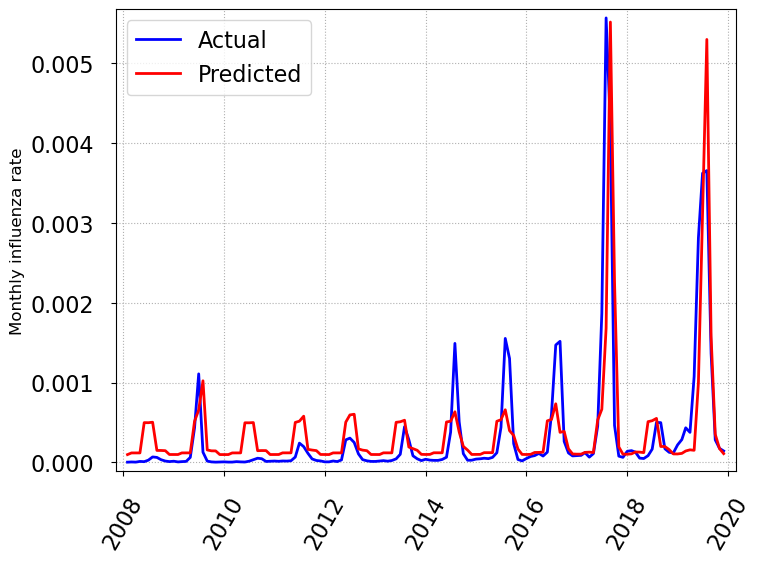

In [18]:
# score_estimator(poisson_cv, y_test = y, X_test = X)
# dates = df_state['date']

# dates_pred = dates[0:] 

# plt.figure(figsize=(8, 6))
# plt.plot(dates, y, 'b', label = 'Actual')
# plt.plot(dates_pred, y_pred, 'r', label = 'Predicted') #use this for others
# plt.legend()
# plt.grid(linestyle=':')
# plt.ylabel("Monthly influenza rate", fontsize=12) 
#     # plt.xlabel("Date", fontsize=12) 
# plt.xticks(rotation= 60) #'vertical'
# plt.margins(0.02)
#     # #plt.savefig(path + '/Results/AbstractPlots/papers_trend_plot.pdf', dpi=300,bbox_inches='tight');
# plt.show()
    

# ax = plt.subplot(2,2,1)
dates = df_procss['date']
plot_pred(dates, y=y, y_pred=y_pred_poiss, split=0)
# plt.show
# df_state['observed'].hist(bins=30, log = True) ## looks like Poisson


# ax = plt.subplot(3,3,2)
# # df_state['rate'].hist(bins=30)
# df_state['rate'].hist(bins=30, log = True) ## looks like Poisson

# dates

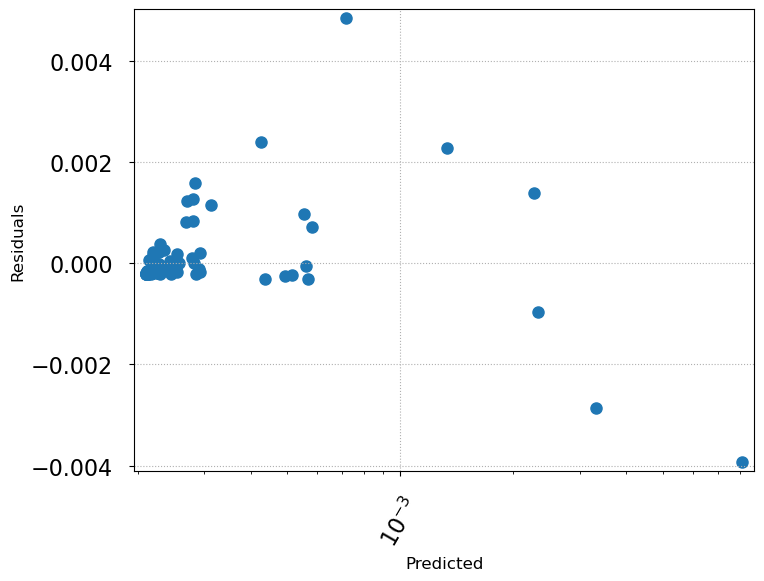

In [35]:
plot_residuals(y, y_pred_poiss)

## Gradient Boosted Regression Tree

In [ ]:
poisson_gbrt = Pipeline(
    [
        ("preprocessor", tree_preprocessor),
        (
            "regressor",
            HistGradientBoostingRegressor(loss="poisson", max_leaf_nodes=128),
        ),r
    ]
)
poisson_gbrt.fit(
    df_train, df_train["Frequency"], regressor__sample_weight=df_train["Exposure"]
)


In [206]:

tree_preprocessor

# def gbrt_reg(X_train, y_train, X_test, y_test):
#     ## define parameters
#     params = {
#         "n_estimators": 500, #the number of boosting stages that will be performed.
#         "max_depth": 4,#limits the number of nodes in the tree. The best value depends on the interaction of the input variables.
#         "min_samples_split": 5, #the minimum number of samples required to split an internal node.
#         "learning_rate": 0.01,#how much the contribution of each tree will shrink.
#         "loss": "squared_error", # loss function to optimize.
#     }
#     # ##Fit regression model
#     gbrt_cv = ensemble.GradientBoostingRegressor(**params,  random_state=0)
#     gbrt_cv.fit(X_train, y_train) #fit training data

#     r2_train = gbrt_cv.score(X_train, y_train).round(4) #R-squared of trainig set
#     r2_test = gbrt_cv.score(X_test, y_test).round(4) #R-squared of test set

#     y_pred = gbrt_cv.predict(X_test)
#     df_y_pred = pd.DataFrame(y_test)
#     df_y_pred['y_pred'] = y_pred.tolist()

#     pcc = df_y_pred.corr()[['rate']].round(4).iloc[1,0] #Pearson Correlation coeff  'lograte'
#     rmse = np.sqrt(mean_squared_error(y_test, y_pred)).round(4) #RMSE of test set
#     mae = mean_absolute_error(y_test, y_pred).round(4) #MA
#     # gbrt_cv
#     print("R squared training set: {}".format(r2_train)) #this is mean R2 value of training set
#     print("R squared: {}".format(r2_test))
#     print("RMSE: {}".format(rmse))
#     print("MAE: {}".format(mae))
#     print("PCC: {}".format(pcc))
     
#     return gbrt_cv, y_pred

R squared training set: 0.9871
R squared: -0.2328
RMSE: 0.0015
MAE: 0.001
PCC: 0.8394


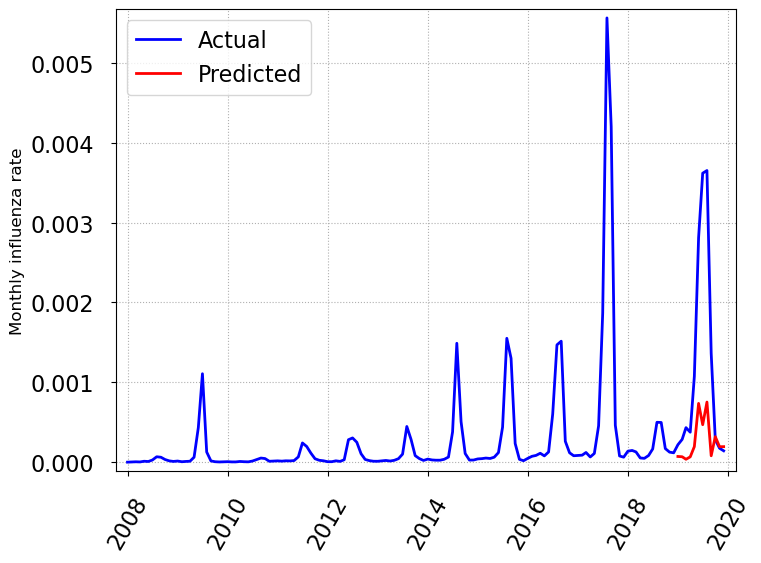

In [207]:
# gbrt, y_pred_gbrt = gbrt_reg(X_train, y_train, X_test, y_test)
gbrt, y_pred_gbrt = gbrt_reg(Xtrans_train, y_train, Xtrans_test, y_test)
# mlpreg_cv_now, y_pred_now = fnn_reg(X_train, y_train, X_test, y_test
dates = df_state['date']
dates

plot_pred(dates, y, y_pred_gbrt, split)
 

## Histogram Boosted Regression Tree

In [211]:
hbrt = HistGradientBoostingRegressor(loss="poisson", max_leaf_nodes=128, random_state=0) ##use default params ##'from_dtype' categorical_features= ['season', 'holiday', 'workingday', 'weather']
hbrt.fit(Xtrans_train,y_train)
y_pred_hbrt = hbrt.predict(Xtrans_test)
y_pred_hbrt

array([9.92544051e-05, 3.17053939e-05, 3.95477377e-05, 7.51765749e-05,
       4.42824526e-04, 1.32506917e-04, 6.42219555e-04, 4.58201383e-04,
       2.35123435e-04, 2.25713296e-04, 9.27599256e-05, 9.33392999e-05])

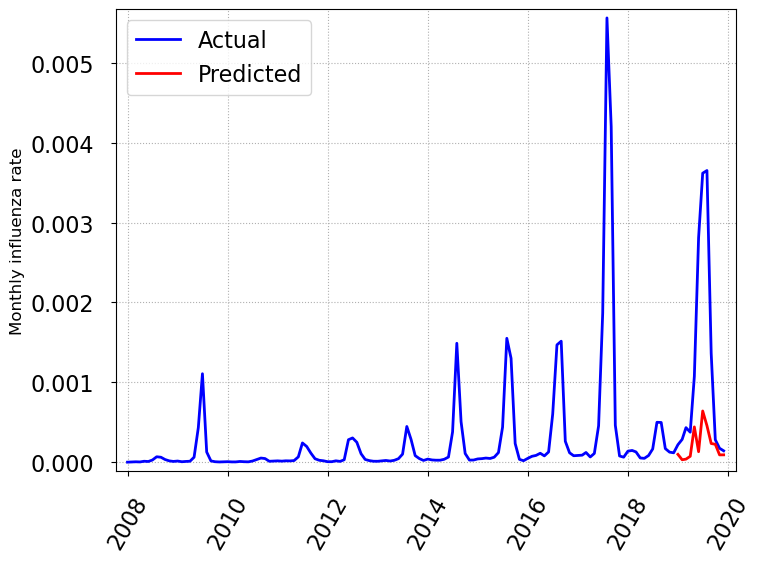

In [212]:
dates = df_state['date']
dates

plot_pred(dates, y, y_pred_hbrt, split)
 


## ------- Initial Poisson regression -- statsmodel

(144, 19)


,date,year,observed,observedFilled,popn,season,tas,tasmax,tasmin,dtr,wet_bulb_temp,RH,pr,rate,obs_lag1,obs_lag2,tas_lag2,dtr_lag2,RH_lag2
0,2008-01-01,2008,12,12,6919907.0,summer,21.597086,26.629333,17.615806,9.013527,21.152640,73.487414,0.000044,0.000002,NaN,NaN,NaN,NaN,NaN
1,2008-02-01,2008,27,27,6919907.0,summer,19.404524,23.926475,15.738856,8.187619,19.157455,73.897354,0.000066,0.000004,12.0,NaN,NaN,NaN,NaN
2,2008-03-01,2008,44,44,6919907.0,autumn,19.029132,24.357966,14.311819,10.046147,18.350708,70.250838,0.000013,0.000006,27.0,12.0,21.597086,9.013527,73.487414
3,2008-04-01,2008,31,31,6943461.0,autumn,14.649582,19.122810,10.818024,8.304786,14.598455,73.127066,0.000026,0.000004,44.0,27.0,19.404524,8.187619,73.897354
4,2008-05-01,2008,90,90,6943461.0,autumn,12.482742,18.002968,7.756017,10.246951,12.541079,72.962613,0.000004,0.000013,31.0,44.0,19.029132,10.046147,70.250838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,2019-08-01,2019,29472,29472,8071350.0,winter,11.260186,16.871173,6.400301,10.470872,10.064879,59.730771,0.000015,0.003651,29202.0,22621.0,11.198368,8.565775,75.488914
140,2019-09-01,2019,11010,11010,8071350.0,spring,14.485836,20.709069,9.283592,11.425476,12.936462,59.243130,0.000025,0.001364,29472.0,29202.0,11.076799,9.477141,66.346392
141,2019-10-01,2019,2287,2287,8088361.0,spring,17.797173,24.558675,11.998411,12.560264,15.532759,56.239008,0.000010,0.000283,11010.0,29472.0,11.260186,10.470872,59.730771
142,2019-11-01,2019,1421,1421,8088361.0,spring,20.520294,27.962736,14.374884,13.587852,17.212884,50.822124,0.000012,0.000176,2287.0,11010.0,14.485836,11.425476,59.243130


In [802]:

y = df_model['observedFilled']##df_state['lograte']
# X = df_procss[['tas', 'tasmax', 'tasmin', 'dtr', 'wet_bulb_temp', 'RH', 'pr', 'season', 'rate_lag1']]
# X = df_procss[['popn','season', 'obs_lag1', 'obs_lag2','tas', 'dtr', 'RH']]
X = df_model[['popn', 'obs_lag1', 'obs_lag2','season', 'tas_lag2', 'dtr_lag2', 'RH_lag2']]
print([y.shape,X.shape])
X.head()


### transform variables
X_trans= (X
    .pipe(pd.get_dummies, columns=['season'])
    # .dropna()
    .assign(intercept=1)  # Adds a column called 'intercept' with all values equal to 1.
    .reset_index(drop=True)
)
# X_trans[['log_obs_lag1','log_obs_lag2','log_tas', 'log_dtr', 'log_RH' ]] = np.log(X_trans[['obs_lag1', 'obs_lag2','tas', 'dtr', 'RH' ]]) #transform to log-scale
X_trans[['log_obs_lag1','log_obs_lag2', 'log_tas_lag2', 'log_dtr_lag2', 'log_RH_lag2' ]] = np.log(X_trans[['obs_lag1', 'obs_lag2','tas_lag2', 'dtr_lag2', 'RH_lag2' ]]) #transform to log-scale

print(X_trans.shape)
X_trans.head()


## convert tas, dtr, wet_bulb_temp, RH on logscale
# X_trans['log_obs_lag1'] = np.log(X_trans['obs_lag1'])
# X_trans['log_tas'] = np.log(X_trans['tas'])
# X_trans['log_dtr'] = np.log(X_trans['dtr'])
# X_trans['log_RH'] = np.log(X_trans['RH'])

print([y.shape,X_trans.shape])
X_trans.head()

[(142,), (142, 7)]


,popn,obs_lag1,obs_lag2,season,tas_lag2,dtr_lag2,RH_lag2
0,6919907.0,27.0,12.0,autumn,21.597086,9.013527,73.487414
1,6943461.0,44.0,27.0,autumn,19.404524,8.187619,73.897354
2,6943461.0,31.0,44.0,autumn,19.029132,10.046147,70.250838
3,6943461.0,90.0,31.0,winter,14.649582,8.304786,73.127066
4,6972395.0,70.0,90.0,winter,12.482742,10.246951,72.962613


(142, 16)
[(142,), (142, 16)]


,popn,obs_lag1,obs_lag2,tas_lag2,dtr_lag2,RH_lag2,season_autumn,season_spring,season_summer,season_winter,intercept,log_obs_lag1,log_obs_lag2,log_tas_lag2,log_dtr_lag2,log_RH_lag2
0,6919907.0,27.0,12.0,21.597086,9.013527,73.487414,1,0,0,0,1,3.295837,2.484907,3.072558,2.198726,4.297114
1,6943461.0,44.0,27.0,19.404524,8.187619,73.897354,1,0,0,0,1,3.784190,3.295837,2.965506,2.102623,4.302677
2,6943461.0,31.0,44.0,19.029132,10.046147,70.250838,1,0,0,0,1,3.433987,3.784190,2.945971,2.307189,4.252072
3,6943461.0,90.0,31.0,14.649582,8.304786,73.127066,0,0,0,1,1,4.499810,3.433987,2.684412,2.116832,4.292199
4,6972395.0,70.0,90.0,12.482742,10.246951,72.962613,0,0,0,1,1,4.248495,4.499810,2.524347,2.326980,4.289947


                 Generalized Linear Model Regression Results                  
Dep. Variable:               observed   No. Observations:                  143
Model:                            GLM   Df Residuals:                      134
Model Family:                 Poisson   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4427e+05
Date:                Fri, 08 Nov 2024   Deviance:                   2.8738e+05
Time:                        12:56:33   Pearson chi2:                 3.60e+05
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept        -2.3719      0.187    -12.703

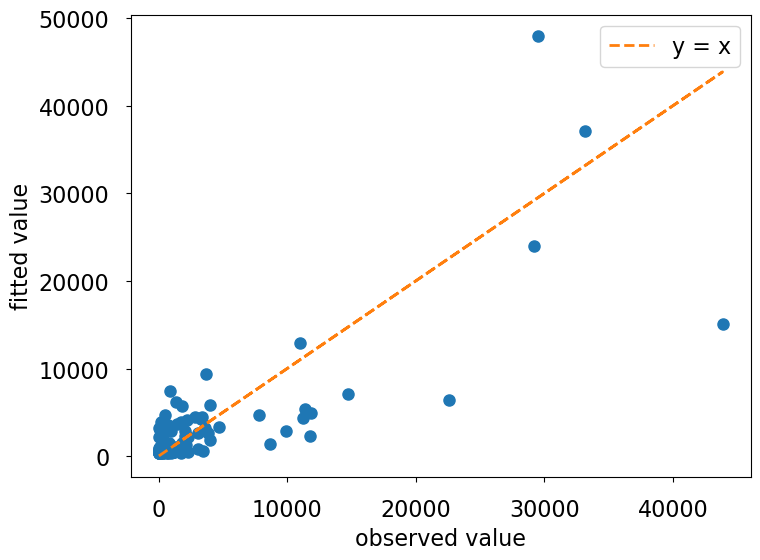

In [140]:
## Model 1 -- no covariates
model_no_covariates = sm.GLM(
    y,
    X_trans['intercept'],
    offset=np.log(X['popn']),
    family=sm.families.Poisson(),
)
result_no_covariates = model_no_covariates.fit()
# print(result_no_covariates.summary()) ##Deviance:9.6297e+05

##############################
## Model 2 -- intercept + lag1
#############################
## Model 2 -- no covariates
model_lag1 = sm.GLM(
    y,
    X_trans[['intercept', 'obs_lag1']],
    offset=np.log(X['popn']),
    family=sm.families.Poisson(),
)
result_lag1 = model_lag1.fit()
# print(result_lag1.summary())  

##############################
## Model 3 -- intercept + lag1 + sesons
#############################
 
model_lag1_seasons = sm.GLM(
    y,
    X_trans[['intercept', 'obs_lag1', 'season_spring','season_summer', 'season_winter']], ## exclude 'season_autumn'
    offset=np.log(X['popn']),
    family=sm.families.Poisson(),
)
result_lag1_season = model_lag1_seasons.fit()
# print(result_lag1_season.summary())  

##############################
## Model 4 -- intercept + lag1 + sesons+tas
#############################
 
model_lag1_seasons_tas = sm.GLM(
    y,
    X_trans[['intercept', 'obs_lag1', 'season_spring','season_summer', 'season_winter','tas']], ## exclude 'season_autumn'
    offset=np.log(X['popn']),
    family=sm.families.Poisson(),
)
result_lag1_season_tas = model_lag1_seasons_tas.fit()
# print(result_lag1_season_tas.summary())   ##Deviance: 2.9567e+05 (tas)

##############################
## Model 5 -- intercept + lag1 + sesons+tas+ dtr
#############################
 
model_lag1_seasons_tas_dtr = sm.GLM(
    y,
    X_trans[['intercept', 'obs_lag1', 'season_spring','season_summer', 'season_winter','tas','dtr']], ## exclude 'season_autumn'
    offset=np.log(X['popn']),
    family=sm.families.Poisson(),
)
result_lag1_season_tas_dtr = model_lag1_seasons_tas_dtr.fit()
# print(result_lag1_season_tas_dtr.summary())   ## 

##############################
## Model 5 -- intercept + lag1 + sesons+tas + dtr + RH 
#############################
model_lag1_seasons_tas_dtr_RH = sm.GLM(
    y,
    X_trans[['intercept', 'obs_lag1', 'season_spring','season_summer', 'season_winter','tas','dtr', 'RH']], ## exclude 'season_autumn'
    offset=np.log(X['popn']),
    family=sm.families.Poisson(),
)
result_lag1_season_tas_dtr_RH = model_lag1_seasons_tas_dtr_RH.fit()
# print(result_lag1_season_tas_dtr_RH.summary())   ## 


##############################
## Model 5 -- intercept + lag1 + sesons+tas + dtr + RH + wet_bulb_temp
#############################
model_lag1_seasons_tas_dtr_RH_wetbulb = sm.GLM(
    y,
    X_trans[['intercept', 'obs_lag1', 'season_spring','season_summer', 'season_winter','tas','dtr', 'RH', 'wet_bulb_temp']], ## exclude 'season_autumn'
    offset=np.log(X['popn']),
    family=sm.families.Poisson(),
)
result_lag1_season_tas_dtr_RH_wetbulb = model_lag1_seasons_tas_dtr_RH_wetbulb.fit()
print(result_lag1_season_tas_dtr_RH_wetbulb.summary())   ## 
##############################
## plot obsd vs predicted plot
##############################
plt.figure(figsize=(8, 6))
# plt.plot(y, result_no_covariates.fittedvalues, 'o')
# plt.plot(y, result_lag1.fittedvalues, 'o')
# plt.plot(y, result_lag1_season.fittedvalues, 'o')
# plt.plot(y, result_lag1_season_tas.fittedvalues, 'o')
# plt.plot(y, result_lag1_season_tas_dtr.fittedvalues, 'o')
# plt.plot(y, result_lag1_season_tas_dtr_RH.fittedvalues, 'o')
plt.plot(y, result_lag1_season_tas_dtr_RH_wetbulb.fittedvalues, 'o')
plt.plot(y, y, '--', label='y = x')
plt.ylabel("fitted value")
plt.xlabel("observed value")
plt.legend()
plt.show()

### Train/test cross validation

In [806]:
lst_fold_idx = df_procss.index[df_procss['year'] >= 2016].tolist()
print(lst_fold_idx) ## 95 to 142
print(len(lst_fold_idx) )
# print(lst_fold_idx[:-1]) ## 95 to 141
# print(len(lst_fold_idx[:-1]))
# print(lst_fold_idx[0:5]) ## 95 to 141
# print(lst_fold_idx[0]) #95
# dates = df_procss['date']
# print(df_state['year'][95]) #95 = start of 2016.. 72 = start of 2014 [132] = ##2019
print(df_procss[['date','year','rate','observed']][lst_fold_idx[0]:])
# split = 95
# split = 132
# i = 0
# split = lst_fold_idx[0]
# y_train = y[:split]; 
# y_test = y[split+0] ## one-step ahead
# # # # y_test1 = y[split:]
# # # # print("y train and test shape:", y_train.shape, y_test.shape) 
# X_train = X_trans.head(split)
# X_test = X_trans.head(split+1)[-1:] 

# # print("X train and test shape:", X_train.shape, X_test.shape)  
# # # X_test
# # Xtrans_train = Xtrans.head(split)
# # Xtrans_test = Xtrans.tail(X.shape[0]-split)
# # Xtrans_test

[94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141]
48
          date  year      rate  observed
94  2016-01-01  2016  0.000049       379
95  2016-02-01  2016  0.000075       579
96  2016-03-01  2016  0.000086       662
97  2016-04-01  2016  0.000113       874
98  2016-05-01  2016  0.000080       621
99  2016-06-01  2016  0.000129       999
100 2016-07-01  2016  0.000604      4688
101 2016-08-01  2016  0.001469     11414
102 2016-09-01  2016  0.001515     11772
103 2016-10-01  2016  0.000263      2050
104 2016-11-01  2016  0.000119       930
105 2016-12-01  2016  0.000082       640
106 2017-01-01  2017  0.000085       668
107 2017-02-01  2017  0.000089       699
108 2017-03-01  2017  0.000123       962
109 2017-04-01  2017  0.000067       523
110 2017-05-01  2017  0.000111       871
111 2017-06-01  2017  0.

In [727]:
# print(X_train.shape)
# print(y_train.shape)
# y_test
# X_train
# X_test
# for split in lst_fold_idx[0:5]:
#     # fold = i
#     # split = lst_fold_idx[fold]
#     # split = fold
#     y_train = y[:split]; 
#     y_test = y[split+1] ## one-step ahead
#     print(y_test)
# # # # y_test1 = y[split:]
# # # # print("y train and test shape:", y_train.shape, y_test.shape) 
#     X_train = X_trans.head(split)
#     X_test = X_trans.head(split+1)[-1:] 
#     print(X_test)

# split_train = lst_fold_idx[0]
# print(split_train)
# y_train = y[:split_train];  ## indx = 0 to 94
# y_test = y[split_train:]  ## indx = 95 to 142
# X_train = X_trans[:split_train]
# X_test = X_trans[split_train:]
# print([y.shape, X.shape]) ##[(143,), (143, 6)]
# print([y_train.shape, X_train.shape]) ##[(95,), (95, 13)] (index = 0 to 94)
# print([y_test.shape, X_test.shape]) ## [(48,), (48, 13)] (index  = 95 to 142)

## check for correct splitting  (pick 1st row of y_test and X_test)
for split in lst_fold_idx[0:5]:
        print(split)
        y_train = y[:split]
        X_train = X_trans[:split] ## 
        if y_train.shape[0]> 95:
                 y_train = y_train.tail(95)#y_train.tail(y_train.shape[0]-1)
                 X_train = X_train.tail(95)
        else: 
                y_train = y_train
                X_train = X_train
        y_test = y[split]##y[split:].head(1)
        X_test = X_trans[split:].head(1)
    
        y_rate  = y_test/X_test['popn'] ## compute rate
        # print([y_train.shape[0], X_train.shape[0]])
        print(y_test)
        # print(y[split]) ## just the observed value
        print(X_test)
        # print(y_rate)
# print(y[split_train]) ### 1st row of test data
# print(X_trans[split_train:].head(1))
# print(lst_fold_idx[0])
# print(y_train)
# df_procss[['date','year','rate','observed']][split_train:] ### test data 
# X_test
# y_test
# X_trans[:split_train]
# y_train

95
379
         popn  obs_lag1        tas       dtr         RH  season_autumn  \
95  7707412.0     152.0  21.741279  9.595169  70.024303              0   

    season_spring  season_summer  season_winter  intercept  log_obs_lag1  \
95              0              1              0          1      5.023881   

     log_tas  log_dtr    log_RH  
95  3.079213  2.26126  4.248842  
96
579
         popn  obs_lag1        tas        dtr         RH  season_autumn  \
96  7707412.0     379.0  22.347009  10.309659  68.481893              0   

    season_spring  season_summer  season_winter  intercept  log_obs_lag1  \
96              0              1              0          1      5.937536   

     log_tas   log_dtr    log_RH  
96  3.106692  2.333081  4.226569  
97
662
         popn  obs_lag1        tas       dtr         RH  season_autumn  \
97  7707412.0     579.0  21.015178  9.717804  71.347588              1   

    season_spring  season_summer  season_winter  intercept  log_obs_lag1  \
97        

### Fit a Poisson model first
- check for overdispersion; If so, fit a negative binomial model

Mean=952.2234042553191 Variance=4580509.705409689
                 Generalized Linear Model Regression Results                  
Dep. Variable:         observedFilled   No. Observations:                   94
Model:                            GLM   Df Residuals:                       85
Model Family:                 Poisson   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -15775.
Date:                Fri, 24 Jan 2025   Deviance:                       30848.
Time:                        15:21:31   Pearson chi2:                 3.04e+04
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

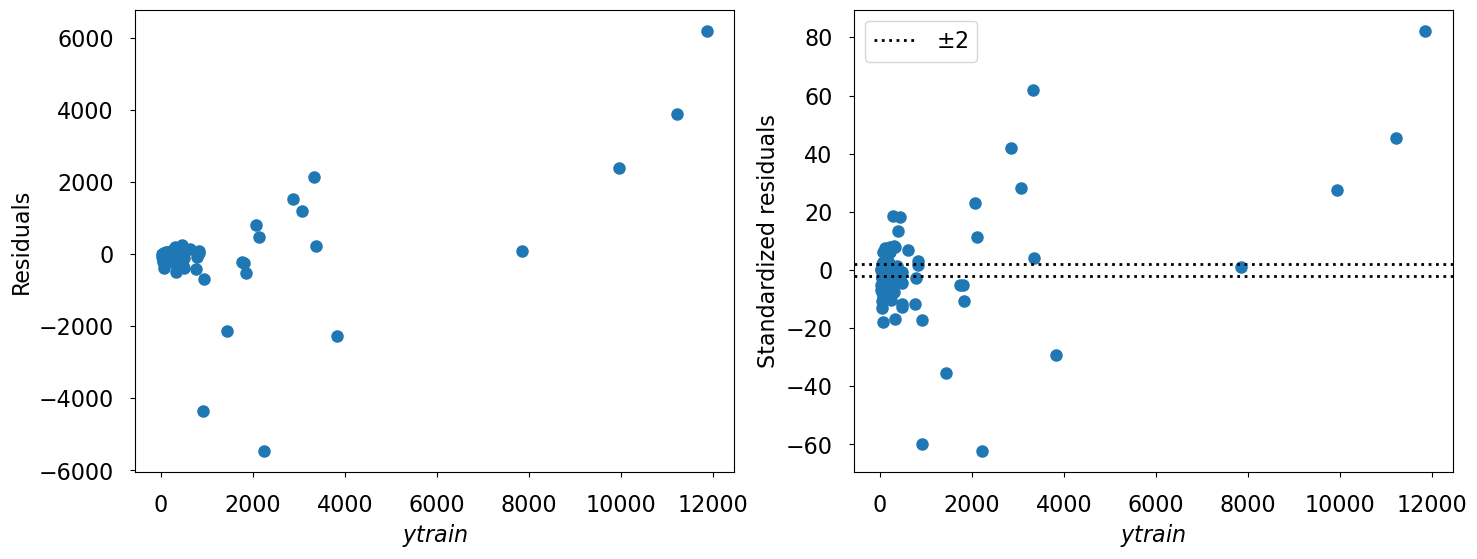

In [553]:
################
### first fit the model to training data only (initial fit) -> Poisson model
#####################
split_train = lst_fold_idx[0]
y_train = y[:split_train];  ## 
X_train =  X_trans[:split_train] ##X_trans.head(split_train)

## check if mean = var 
print('Mean='+str(np.mean(y_train)) + ' Variance='+str(np.var(y_train))) ## Mean=942.4842105263158 Variance=4541209.891855954

modl_train_poiss = sm.GLM(
        y_train,
        # X_train[['intercept', 'log_obs_lag1', 'season_spring','season_summer', 'season_winter','tas','dtr', 'RH']], ## exclude 'season_autumn'
        X_train[['intercept', 'log_obs_lag1', 'log_obs_lag2','season_spring','season_summer', 'season_winter','log_tas', 'log_dtr', 'log_RH']], ## exclude 'season_autumn'
        offset=np.log(X_train['popn']),
        family=sm.families.Poisson(),
    )
res_train_poiss = modl_train_poiss.fit()
print(res_train_poiss.summary())
# res_train.params
## res_train.fittedvalues ## fitted values are counts (0, ..., 95 values)
######
## get predictions on linear scale (the rate)
#########
# y_pred_train = res.predict(X_train[['intercept', 'obs_lag1', 'season_spring','season_summer', 'season_winter','tas','dtr', 'RH']])
y_pred_train_poiss = res_train_poiss.predict(X_train[['intercept', 'log_obs_lag1', 'log_obs_lag2','season_spring','season_summer', 'season_winter','log_tas', 'log_dtr', 'log_RH']])
y_rate_train = y_train/X_train['popn']

###########
## compute overdispersion ratio
###########
R = res_train_poiss.pearson_chi2 / res_train_poiss.df_resid
print("overdispersion ratio: {}".format(R.round(4)))  #385.39 >>1. so overdispersed   
 

################
## plot residuals and standardised residuals
## If Poisson -> residuals will have mean 0 and no obvious patterns 
### If Poisson, -> standardised residuals will have mean 0 and sd =1; and 95% of points must be within 2 std.devaiations
#############################
figure, axes = plt.subplots(1, 2, figsize=(17, 6))
axes[0].plot(y_train, res_train_poiss.resid_response, 'o')
axes[0].set_ylabel("Residuals")
axes[0].set_xlabel("$ytrain$")
axes[1].plot(y_train, res_train_poiss.resid_pearson, 'o') ## standardised residuals
axes[1].axhline(y=-2, linestyle=':', color='black', label='$\pm 2$')
axes[1].axhline(y=+2, linestyle=':', color='black')
axes[1].set_ylabel("Standardized residuals")
axes[1].set_xlabel("$ytrain$")
plt.legend()
plt.show()

In [732]:
X_trans.head()

,popn,obs_lag1,obs_lag2,tas,dtr,RH,season_autumn,season_spring,season_summer,season_winter,intercept,log_obs_lag1,log_obs_lag2,log_tas,log_dtr,log_RH
0,6919907.0,27.0,12.0,19.029132,10.046147,70.250838,1,0,0,0,1,3.295837,2.484907,2.945971,2.307189,4.252072
1,6943461.0,44.0,27.0,14.649582,8.304786,73.127066,1,0,0,0,1,3.784190,3.295837,2.684412,2.116832,4.292199
2,6943461.0,31.0,44.0,12.482742,10.246951,72.962613,1,0,0,0,1,3.433987,3.784190,2.524347,2.326980,4.289947
3,6943461.0,90.0,31.0,12.043396,7.069563,77.927723,0,0,0,1,1,4.499810,3.433987,2.488516,1.955799,4.355782
4,6972395.0,70.0,90.0,9.442759,8.743098,69.461158,0,0,0,1,1,4.248495,4.499810,2.245248,2.168265,4.240768


### Fit a negative binomial model

In [797]:
###################################
## First choose the overdispersion parameter using the discrete_model API; alpha 
###############################
split_train = lst_fold_idx[0]
y_train = y[:split_train];  ## 
X_train =  X_trans[:split_train] ##X_trans.head(split_train)

nb_modl_train = dm.NegativeBinomial(
    y_train,
    # X_train[['intercept', 'log_obs_lag1', 'log_obs_lag2','season_spring','season_summer', 'season_winter','log_tas','log_dtr', 'log_RH']], ## exclude 'season_autumn',
    X_train[['intercept', 'log_obs_lag1', 'log_obs_lag2','season_spring','season_summer', 'season_winter', 'log_tas_lag2','log_dtr_lag2', 'log_RH_lag2']],
    offset=np.log(X_train['popn']),
)

nb_res_train = nb_modl_train.fit(maxiter = 60)
print(nb_res_train.summary())   ## this gives alpha = 0.2771 and is significant at 95% CI


###########################
## now fit negative binomial model using GLM model
#######################
##alpha =  0.2847  ##0.6396 (lag2) #0.2847 (lag1) ## 0.2771(no lag) ## lags indicate for climate variables (for NSW)
alpha =   0.2670
nb_modl_train_glm = sm.GLM(
    y_train,
    # X_train[['intercept', 'log_obs_lag1', 'season_spring','season_summer', 'season_winter','log_tas','log_dtr', 'log_RH']],
    # X_train[['intercept', 'log_obs_lag1', 'log_obs_lag2','season_spring','season_summer', 'season_winter','log_tas', 'log_dtr', 'log_RH']],
    X_train[['intercept', 'log_obs_lag1', 'log_obs_lag2', 'season_spring','season_summer', 'season_winter', 'log_tas_lag2','log_dtr_lag2', 'log_RH_lag2']],
    offset=np.log(X_train['popn']),
    family=sm.families.NegativeBinomial(alpha=alpha),
)
res_nb_modl_train_glm = nb_modl_train_glm.fit()
print(res_nb_modl_train_glm.summary())  

#####
# get predictions on linear scale (the rate)
########
# y_pred_train = res.predict(X_train[['intercept', 'obs_lag1', 'season_spring','season_summer', 'season_winter','tas','dtr', 'RH']])
# y_pred_train_nb = res_nb_modl_train_glm.predict(X_train[['intercept', 'log_obs_lag1', 'log_obs_lag2','season_spring','season_summer', 'season_winter','log_tas', 'log_dtr', 'log_RH']])
y_pred_train_nb = res_nb_modl_train_glm.predict(X_train[['intercept', 'log_obs_lag1', 'log_obs_lag2', 'season_spring','season_summer', 'season_winter', 'log_tas_lag2','log_dtr_lag2', 'log_RH_lag2']])
y_rate_train_nb = y_train/X_train['popn']

################
# plot residuals and standardised residuals
# If Poisson -> residuals will have mean 0 and no obvious patterns 
## If Poisson, -> standardised residuals will have mean 0 and sd =1; and 95% of points must be within 2 std.devaiations
############################
figure, axes = plt.subplots(1, 2, figsize=(17, 6))
axes[0].plot(y_train, res_nb_modl_train_glm.resid_response, 'o')
axes[0].set_ylabel("Residuals")
axes[0].set_xlabel("$ytrain$")
axes[1].plot(y_train, res_nb_modl_train_glm.resid_pearson, 'o') ## standardised residuals
axes[1].axhline(y=-1, linestyle=':', color='black', label='$\pm 2$')
axes[1].axhline(y=+1, linestyle=':', color='black')
axes[1].set_ylabel("Standardized residuals")
axes[1].set_xlabel("$ytrain$")
plt.legend()
plt.show()

NameError: name 'X_trans' is not defined

In [818]:
# rmse_all
# y_pred_all
# y_pred_all
  ##

# # for fold in lst_fold_idx[0:2]:
#     deviance_all[fold] =  deviance 
#     mae_all[fold] = mae 
#     rmse_all[fold] = rmse 
# lst_fold_idx[fold]
# for i in range(len(lst_fold_idx)-23):
#     print(i)
# print(len(lst_fold_idx))
# print(len(list(y_pred_all.values())))
np.mean(list(mae_all.values())).round(8)  ## get mean of mae from all folds
# mae_all
# 0.00030582*10000


0.000267/0.00079 ## comparision of MAE with sd of validation set (MAE/sd)


0.7867088607594936

,result,95,96,97,98,99,100,101,102,103,...,133,134,135,136,137,138,139,140,141,142
0,y_pred,0.000115,0.000100,0.000074,0.000058,0.000154,0.000156,0.000179,0.000242,0.000416,...,0.000200,0.000307,0.000723,0.001397,0.000717,0.000706,0.000577,0.000508,0.000394,0.000224
1,deviance,104.785512,104.704026,103.993751,102.735484,100.233272,97.012849,97.266251,96.752464,96.872592,...,83.900009,83.985550,84.332650,82.603730,83.311717,83.131641,81.656875,79.870767,77.577191,77.418127
2,mae,0.000032,0.000006,0.000017,0.000052,0.000084,0.000115,0.000037,0.000087,0.000602,...,0.000251,0.000776,0.000360,0.000821,0.000137,0.000077,0.000054,0.000191,0.000073,0.000487
3,rmse,0.000032,0.000006,0.000017,0.000052,0.000084,0.000115,0.000037,0.000087,0.000602,...,0.000251,0.000776,0.000360,0.000821,0.000137,0.000077,0.000054,0.000191,0.000073,0.000487
4,intercept,7.460075,6.499237,6.289647,6.838147,8.494967,8.069466,11.547606,8.443499,8.366518,...,-3.790615,-5.028020,-2.850646,-0.939192,-3.414497,-2.810927,-3.272029,-4.110032,-4.105745,-4.240086
5,obs_lag1,0.577005,0.581237,0.583534,0.584556,0.589100,0.570326,0.563562,0.572263,0.572567,...,0.625485,0.651154,0.691518,0.696390,0.681479,0.681454,0.688294,0.693463,0.691616,0.687299
6,season_spring,0.587055,0.558344,0.528150,0.481699,0.342739,0.419246,0.424819,0.418077,0.408935,...,0.716709,0.611628,0.451583,0.464991,0.464953,0.466109,0.405962,0.432517,0.486498,0.484655
7,season_summer,0.185135,0.178425,0.134745,0.138432,0.103732,0.138784,0.178749,0.183828,0.173883,...,0.201271,0.082112,-0.043745,-0.026285,-0.005539,-0.011571,-0.073210,-0.084126,-0.098405,-0.074097
8,season_winter,0.088530,0.084954,0.077976,0.000336,-0.185619,-0.069406,-0.160580,-0.221516,-0.186102,...,0.817188,0.773662,0.520992,0.440388,0.415673,0.393890,0.503334,0.525946,0.560874,0.549345
9,tas,-5.460282,-5.326970,-5.245745,-5.324083,-5.414278,-5.372765,-5.741085,-5.779088,-5.675926,...,-0.171832,-0.048837,-0.736161,-1.446420,-1.327208,-1.316406,-0.920694,-0.851861,-0.977598,-1.033404


In [813]:
# len(list(y_pred_all.values()))
del y_preds
# y_pred_train_nb

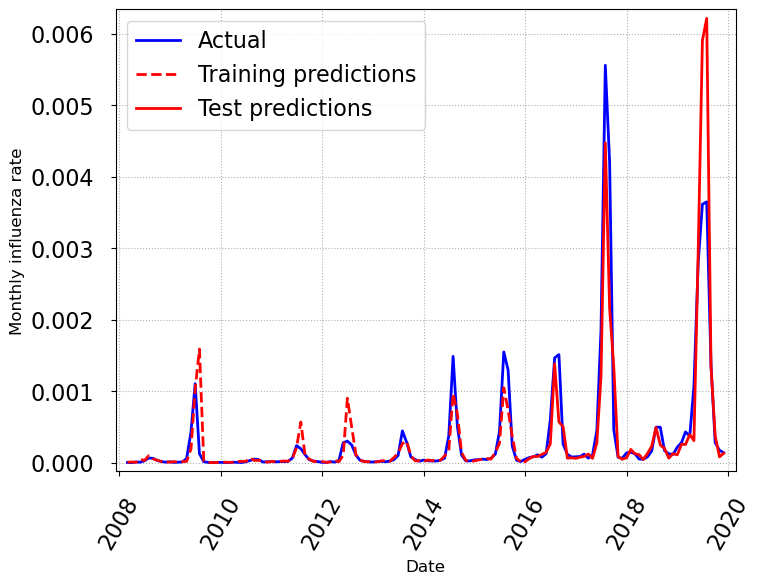

In [814]:
## plot obs Pred
dates = df_procss['date']
dates
dates_pred = df_procss[df_procss['year'] >= 2016].date
dates_train = df_procss[df_procss['year'] < 2016].date
# print(len(dates_pred))
# print(dates_pred.values)
# y_preds = res_nsw[res_nsw['result'] == 'y_pred'].drop('result', axis=1)
y_preds = list(y_pred_all.values())
# print(type(y_preds))
# y_preds.T[0:25]
# dates_train
# y_pred_train
# plot_pred(dates, y, y_pred_hbrt, split)
# def plot_pred(dates, y, y_pred, split): 

#     dates_pred = dates[split:] # 
#     # print(type(dates), dates.shape, dates_pred.shape, y_pred.shape)  #pandas series  208

###plot figure
plt.figure(figsize=(8, 6))
# plt.plot(dates, df_procss['rate'], 'b', label = 'Actual')
plt.plot(dates, df_procss['observed']/df_procss['popn'], 'b', label = 'Actual')
# plt.plot(dates_train, y_pred_train_poiss, '--r', label = 'Training predictions')
plt.plot(dates_train, y_pred_train_nb, '--r', label = 'Training predictions')
# y_pred_train_nb
# plt.plot(dates_pred, y_preds.T, 'r', label = 'Test predictions') #use this for others  y_preds.T[0:20]
plt.plot(dates_pred, y_preds, 'r', label = 'Test predictions') 
plt.legend()
plt.grid(linestyle=':')
plt.ylabel("Monthly influenza rate", fontsize=12) 
plt.xlabel("Date", fontsize=12) 
plt.xticks(rotation= 60) #'vertical'
plt.margins(0.02)
#     # #plt.savefig(path + '/Results/AbstractPlots/papers_trend_plot.pdf', dpi=300,bbox_inches='tight');
plt.show()

### Compare errors for the forecasted period: 

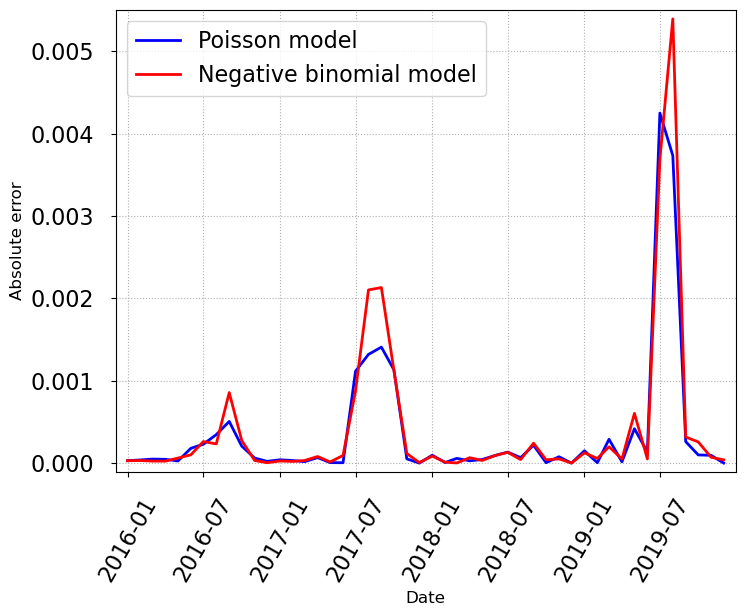

In [459]:
##read saved results
res_poiss = pd.read_csv(path + 'results/infl_paper/nsw_poiss.csv', low_memory=False)
mae_poiss = res_poiss[res_poiss['result'] == 'mae'].drop('result', axis=1)

res_nb = pd.read_csv(path + 'results/infl_paper/nsw_nb.csv', low_memory=False)
mae_nb = res_nb[res_nb['result'] == 'mae'].drop('result', axis=1)

dates = df_procss['date']
dates
dates_pred = df_procss[df_procss['year'] >= 2016].date

res_poiss
mae_poiss
mae_nb

###plot figure
plt.figure(figsize=(8, 6))
plt.plot(dates_pred, mae_poiss.T, 'b', label = 'Poisson model')
plt.plot(dates_pred, mae_nb.T, 'r', label = 'Negative binomial model') #use this for others  y_preds.T[0:20]
plt.legend()
plt.grid(linestyle=':')
plt.ylabel("Absolute error", fontsize=12) 
plt.xlabel("Date", fontsize=12) 
plt.xticks(rotation= 60) #'vertical'
plt.margins(0.02)
#     # #plt.savefig(path + '/Results/AbstractPlots/papers_trend_plot.pdf', dpi=300,bbox_inches='tight');
plt.show()


In [473]:
print('MAE Poisson model: ', mae_poiss.mean(axis=1).values[0].round(5))
print('MAE Negative binomial model: ',mae_nb.mean(axis=1).values[0].round(5))

MAE Poisson model:  0.00036
MAE Negative binomial model:  0.00042


# ----- Compare parameters of. fits for forecasted period:  --------

In [477]:
del intcpt

In [484]:
states = ['NSW', 'QLD', 'VIC', 'SA', 'TAS',  'WA', 'NT']
 

for state in states[0:2]:  
    print(state) 
    intcpt = pd.read_csv(path + 'results/infl_paper/' + state + '_nb.csv', low_memory=False) 
    intcpt = intcpt[intcpt['result'] == 'intercept'].drop('result', axis=1)
intcpt    

NSW
QLD


,95,96,97,98,99,100,101,102,103,104,...,133,134,135,136,137,138,139,140,141,142
4,4.402006,2.5624,0.882799,0.450441,-0.393547,-3.342837,-4.400894,-15.038724,-14.234902,-12.319884,...,0.467188,-2.057307,-1.794343,-1.591317,-1.998714,-2.335767,-2.192487,-2.499441,-1.629513,-0.195983


In [485]:
pd.read_csv(path + 'results/infl_paper/QLD_nb.csv', low_memory=False) #[res_nsw['result'] == 'intercept'].drop('result', axis=1)
    # intercept_nsw = res_nsw[res_nsw['result'] == 'intercept'].drop('result', axis=1)

,result,95,96,97,98,99,100,101,102,103,...,133,134,135,136,137,138,139,140,141,142
0,y_pred,0.000044,0.000068,0.000112,0.000193,0.000229,0.000363,0.000368,0.000943,0.000567,...,0.000337,0.000604,0.000602,0.001604,0.003538,0.005576,0.002380,0.000951,0.000218,0.000172
1,deviance,99.245476,100.964105,102.416138,103.595704,102.747367,100.811587,100.594998,97.523715,97.061005,...,63.105701,64.157666,63.560508,63.617366,63.441027,63.271023,63.175942,62.059291,64.292820,64.262803
2,mae,0.000043,0.000077,0.000105,0.000003,0.000106,0.000234,0.000090,0.000303,0.000816,...,0.000253,0.000064,0.000127,0.000024,0.001240,0.001291,0.000450,0.000602,0.000064,0.000058
3,rmse,0.000043,0.000077,0.000105,0.000003,0.000106,0.000234,0.000090,0.000303,0.000816,...,0.000253,0.000064,0.000127,0.000024,0.001240,0.001291,0.000450,0.000602,0.000064,0.000058
4,intercept,4.402006,2.562400,0.882799,0.450441,-0.393547,-3.342837,-4.400894,-15.038724,-14.234902,...,0.467188,-2.057307,-1.794343,-1.591317,-1.998714,-2.335767,-2.192487,-2.499441,-1.629513,-0.195983
5,obs_lag1,0.803468,0.804572,0.808386,0.818514,0.813685,0.797840,0.785350,0.809137,0.809805,...,0.891212,0.906440,0.902106,0.907265,0.909109,0.905774,0.901049,0.896763,0.882962,0.882594
6,season_spring,-0.524165,-0.547346,-0.589405,-0.660531,-0.683919,-0.615441,-0.604818,-0.594388,-0.626882,...,-0.616350,-0.663068,-0.674938,-0.694315,-0.693478,-0.685300,-0.665090,-0.626216,-0.624520,-0.622860
7,season_summer,0.145920,0.175797,0.184056,0.098127,0.099677,0.113395,0.134021,0.146920,0.125858,...,-0.021115,-0.074897,-0.066302,-0.071022,-0.077097,-0.077229,-0.063170,-0.055035,-0.064827,-0.029143
8,season_winter,0.277254,0.270273,0.265714,0.254338,0.196424,0.310205,0.284475,0.272759,0.311206,...,0.802995,0.813829,0.761171,0.735105,0.739718,0.747033,0.718153,0.728313,0.743116,0.716439
9,tas,-2.648101,-2.588138,-2.469396,-2.303391,-2.392059,-2.285620,-2.370063,-2.198235,-2.108962,...,-0.393098,-0.221010,-0.343594,-0.366649,-0.320225,-0.312543,-0.392520,-0.412470,-0.398091,-0.534357


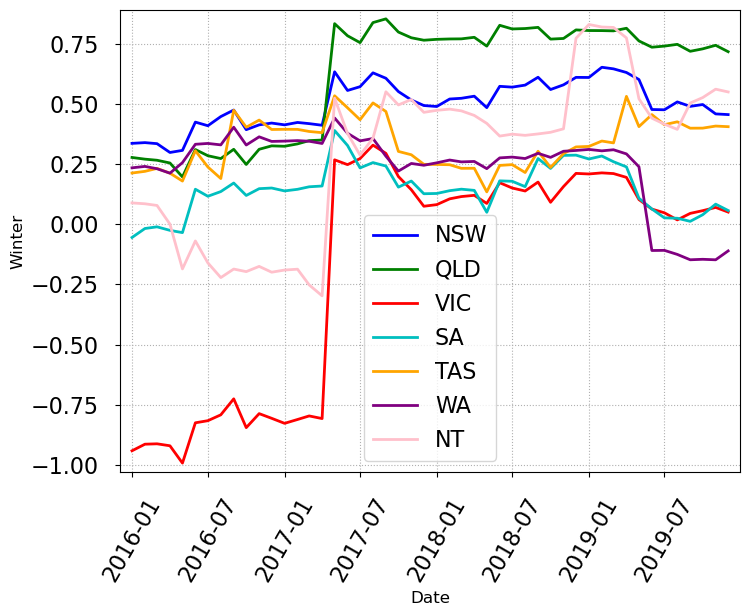

In [511]:
dates = df_procss['date']
dates
dates_pred = df_procss[df_procss['year'] >= 2016].date  #48 values
# len(dates_pred)
# intercept_nsw

states = ['NSW', 'QLD', 'VIC', 'SA', 'TAS',  'WA', 'NT']
colrs = ['b', 'g', 'r', 'c', 'orange', 'purple', 'pink' ]

###plot figure
plt.figure(figsize=(8, 6))
# for state in states[0:2]:  
for i in range(0,7):    ## range(0,7)
    # print(states[i]) 
    # print(colrs[i])
    state = states[i]; colr = colrs[i]
    # print(state) 
    # print(colr)
    intcpt = pd.read_csv(path + 'results/infl_paper/' + state + '_nb.csv', low_memory=False) 
    intcpt = intcpt[intcpt['result'] == 'season_winter'].drop('result', axis=1)
    plt.plot(dates_pred, intcpt.T, color = colr, label = state)
# # plt.plot(dates_pred, mae_nb.T, 'r', label = 'Negative binomial model') #use this for others  y_preds.T[0:20]
plt.legend()
plt.grid(linestyle=':')
plt.ylabel("Winter", fontsize=12) 
plt.xlabel("Date", fontsize=12) 
plt.xticks(rotation= 60) #'vertical'
plt.margins(0.02)
# #     # #plt.savefig(path + '/Results/AbstractPlots/papers_trend_plot.pdf', dpi=300,bbox_inches='tight');
plt.show()

# ---- Elastic net rigression (ignore) ------

In [ ]:
#ElasticNetCV

# def enet_reg(X_train, y_train, X_test, y_test):
    
#     param_grid = {'l1_ratio': [.01, .1, .5, .7, .9, .95, .99, 1] } ##[.01, .1, .5, .7, .9, .95, .99, 1] #np.linspace(0.1, 1, 30) 
#     # param_grid = [.01, .1, .5, .7, .9, .95, .99, 1]
    
#     # # Setup the ElasticNetCV object: 
#     # enet_cv =  ElasticNetCV(cv=5, l1_ratio = param_grid, positive = False,
#     #                random_state = 0)  
#     elastic_net = ElasticNet(random_state = 0, positive = False,)
#     tscv = TimeSeriesSplit(n_splits=5, test_size = 12 ) ##timeseries split


#     enet_cv =  GridSearchCV(elastic_net, param_grid = param_grid,  cv= tscv, scoring='neg_mean_absolute_error')  
#     # Fit it to the training data
#     enet_cv.fit(X_train, y_train)
#     # R2 on training set
#     r2_train = enet_cv.score(X_train, y_train).round(4) #R-squared 
#     r2_test = enet_cv.score(X_test, y_test).round(4) #R-squared of test set
    
#     # Predict on the test set and compute metrics
#     y_pred = enet_cv.predict(X_test)
#     df_y_pred = pd.DataFrame(y_test)
#     df_y_pred['y_pred'] = y_pred.tolist()
    
#     #print(df_y_pred) #for some NT forecasts, y_pred is same so corr() produced nan
#     # pcc = df_y_pred.corr()[['lograte']].round(4).iloc[1,0] #Pearson Correlation coeff 
#     pcc = df_y_pred.corr()[['rate']].round(4).iloc[1,0] #Pearson Correlation coeff 
    
#     rmse = np.sqrt(mean_squared_error(y_test, y_pred)).round(4) #RMSE of test set
#     mae = mean_absolute_error(y_test, y_pred).round(4) #MAE of test set
#     print("Tuned params: {}".format(enet_cv.best_params_))
#     # print("Tuned  l1 ratio: {}".format(enet_cv.l1_ratio_))
#     # print("Tuned  alpha: {}".format(enet_cv.alpha_.round(1)))
#     # print("Tuned RMSE: {}".format(np.sqrt(min(enet_cv.mse_path_.mean(axis =1)).round(4)))) 
#     print("Tuned error: {}".format(-enet_cv.best_score_)) #this is mean R2 value of trainign set  
#     # print("Treaining error: {}".format(r2_train))
#     # print("R squared: {}".format(r2_test))
#     print("RMSE: {}".format(rmse))
#     print("MAE: {}".format(mae))
#     print("PCC: {}".format(pcc))
    
#        #number of features and their names seen during fit 
# #     print('nor. of features cv: {}'.format(enet_cv.n_features_in_))
# #     print('names of features cv: {}'.format(enet_cv.feature_names_in_))
   
#  #### #refit model with best parameters and get important features #####
# # ## Extract the l1_ratio, alpha, max_iter from cv model
# #     alpha = enet_cv.alpha_.round(1)
# #     l1ratio = enet_cv.l1_ratio_
# #     maxiter = enet_cv.n_iter_
# #     print("alpha: {}".format(alpha))
# #     print('l1 ratio: {}'.format(l1ratio)) 
# #     print("max iter: {}".format(maxiter))
    
# #     enet_refit = ElasticNet(alpha = alpha, l1_ratio=l1ratio,  max_iter=maxiter, fit_intercept=True, random_state=0)
# #     enet_refit.fit(X_train, y_train)
    
# #      #number of features and their names seen during fit 
# #     # print('nor. of features: {}'.format(enet_refit.n_features_in_))
# #     # print('names of features: {}'.format(enet_refit.feature_names_in_))
# #     feature_importance = pd.Series(index = X_train.columns, data = np.abs(enet_refit.coef_)).sort_values(ascending=False)
# #     # print(feature_importance.values)
# #     n_selected_features = (feature_importance>0).sum()
# #     print('{0:d} features, reduction of {1:2.2f}%'.format(n_selected_features,(1-n_selected_features/len(feature_importance))*100))
# #     # Make a line graph
# #     # feature_importance.sort_values().tail(30).plot(kind = 'bar',figsize = (10,6)).grid(linestyle = ':') #
# #     # plt.bar(feature_importance.index, feature_importance.values)
# #     plt.plot(feature_importance.index, feature_importance.values, color = 'g',)
# #     plt.hlines(y = 0.1, xmin=0, xmax=len(feature_importance.index), color = 'r', linestyles = 'dashed')
# #     plt.xticks(feature_importance.index, feature_importance.index, rotation = 'vertical')
# #     plt.grid(linestyle=':')
# #     # plt.xlabel(' '); 
# #     plt.ylabel('Absolule value of coefficients'); 
#     return enet_cv, y_pred
